Preguntas:
1. ¿Por qué eligieron ese ambiente?
2. ¿Por qué DQN es razonable para ese escenario?
3. ¿Cuál es la diferencia entre online network y target network?
4. ¿Qué guarda el replay buffer?
5. ¿Cómo definieron ε y su decaimiento?
6. ¿Qué significa que la recompensa mejore o se estanque?
7. ¿Qué cambiarían con más tiempo o capacidad de cómputo?

# Crear entorno Mini Tetris

## Librerías e instalaciones necesarias

### Instalar gymnasium

In [1]:
!pip install gymnasium matplotlib numpy -q

### Importaciones

In [2]:
import gymnasium as gym
from gymnasium import spaces

import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, clear_output
import time

## Crear minitetris utilizando gymnasium personalizado

In [3]:
class MiniTetrisEnv(gym.Env):
    """
    MiniTetris 10x6 para Deep Q-Learning.

    Estado:
        - 60 celdas del tablero
        - 7 valores one-hot para la pieza actual
        Total: 67 valores

    Acción:
        - 4 rotaciones x 6 columnas
        Total: 24 acciones

    Cada acción coloca directamente la pieza
    usando una combinación rotación + columna.
    """

    metadata = {
        "render_modes": ["human"],
        "render_fps": 4
    }

    # Tetrominós básicos
    PIECES = {
        "I": np.array([
            [1, 1, 1, 1]
        ], dtype=np.int8),

        "O": np.array([
            [1, 1],
            [1, 1]
        ], dtype=np.int8),

        "T": np.array([
            [1, 1, 1],
            [0, 1, 0]
        ], dtype=np.int8),

        "S": np.array([
            [0, 1, 1],
            [1, 1, 0]
        ], dtype=np.int8),

        "Z": np.array([
            [1, 1, 0],
            [0, 1, 1]
        ], dtype=np.int8),

        "J": np.array([
            [1, 0, 0],
            [1, 1, 1]
        ], dtype=np.int8),

        "L": np.array([
            [0, 0, 1],
            [1, 1, 1]
        ], dtype=np.int8),
    }

    def __init__(self, render_mode=None, max_pieces=None):

        super().__init__()

        self.rows = 10
        self.cols = 6

        self.render_mode = render_mode
        self.max_pieces = max_pieces

        self.piece_names = list(self.PIECES.keys())

        # 4 rotaciones x 6 columnas
        self.action_space = spaces.Discrete(24)

        # 60 celdas + 7 valores one-hot
        self.observation_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(67,),
            dtype=np.float32
        )

        self.board = None
        self.current_piece_idx = None

        self.lines_cleared = 0
        self.pieces_placed = 0

        # Variables para render
        self.fig = None
        self.ax = None

    # =========================================================
    # RESET
    # =========================================================

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.board = np.zeros(
            (self.rows, self.cols),
            dtype=np.int8
        )

        self.lines_cleared = 0
        self.pieces_placed = 0

        self.current_piece_idx = int(
            self.np_random.integers(len(self.piece_names))
        )

        observation = self._get_observation()
        info = self._get_info()

        return observation, info

    # =========================================================
    # STEP
    # =========================================================

    def step(self, action):

        action = int(action)

        if not self.action_space.contains(action):
            raise ValueError(f"Acción inválida: {action}")

        action_mask = self.get_action_mask()

        # -----------------------------------------------------
        # Acción físicamente imposible
        # -----------------------------------------------------

        if not action_mask[action]:

            reward = -1.0
            terminated = False
            truncated = False

            observation = self._get_observation()
            info = self._get_info()
            info["invalid_action"] = True

            return (
                observation,
                reward,
                terminated,
                truncated,
                info
            )

        # -----------------------------------------------------
        # Decodificar acción
        # -----------------------------------------------------

        rotation = action // self.cols
        column = action % self.cols

        shape = self._get_rotated_piece(
            self.current_piece_idx,
            rotation
        )

        row = self._find_drop_row(
            shape,
            column
        )

        # -----------------------------------------------------
        # Colocar pieza
        # -----------------------------------------------------

        height, width = shape.shape

        self.board[
            row:row + height,
            column:column + width
        ] |= shape

        self.pieces_placed += 1

        # -----------------------------------------------------
        # Eliminar líneas
        # -----------------------------------------------------

        cleared = self._clear_lines()

        self.lines_cleared += cleared

        # Recompensa inicial
        reward_table = {
            0: 0.0,
            1: 1.0,
            2: 3.0,
            3: 5.0,
            4: 8.0
        }

        reward = reward_table[cleared]

        # -----------------------------------------------------
        # Generar nueva pieza
        # -----------------------------------------------------

        self.current_piece_idx = int(
            self.np_random.integers(len(self.piece_names))
        )

        # -----------------------------------------------------
        # Game Over
        # -----------------------------------------------------

        terminated = not self.get_action_mask().any()

        if terminated:
            reward -= 1.0

        # -----------------------------------------------------
        # Truncamiento opcional
        # -----------------------------------------------------

        truncated = False

        if (
            self.max_pieces is not None
            and self.pieces_placed >= self.max_pieces
            and not terminated
        ):
            truncated = True

        observation = self._get_observation()
        info = self._get_info()

        return (
            observation,
            reward,
            terminated,
            truncated,
            info
        )

    # =========================================================
    # OBSERVACIÓN
    # =========================================================

    def _get_observation(self):

        board_flat = self.board.flatten().astype(
            np.float32
        )

        piece_one_hot = np.zeros(
            len(self.piece_names),
            dtype=np.float32
        )

        piece_one_hot[self.current_piece_idx] = 1.0

        observation = np.concatenate(
            [
                board_flat,
                piece_one_hot
            ]
        )

        return observation

    # =========================================================
    # INFO
    # =========================================================

    def _get_info(self):

        return {
            "piece": self.piece_names[
                self.current_piece_idx
            ],

            "lines_cleared": self.lines_cleared,

            "pieces_placed": self.pieces_placed,

            "action_mask": self.get_action_mask(),

            "reached_piece_limit": (
                self.max_pieces is not None
                and self.pieces_placed >= self.max_pieces
            )
        }
    # =========================================================
    # ROTACIÓN
    # =========================================================

    def _get_rotated_piece(
        self,
        piece_idx,
        rotation
    ):

        piece_name = self.piece_names[piece_idx]

        piece = self.PIECES[piece_name]

        # np.rot90 con signo negativo =
        # rotación horaria
        rotated = np.rot90(
            piece,
            -rotation
        )

        return rotated.copy()

    # =========================================================
    # COMPROBAR SI UNA PIEZA CABE
    # =========================================================

    def _can_place(
        self,
        shape,
        row,
        column
    ):

        height, width = shape.shape

        # Fuera del tablero
        if row < 0:
            return False

        if column < 0:
            return False

        if row + height > self.rows:
            return False

        if column + width > self.cols:
            return False

        board_section = self.board[
            row:row + height,
            column:column + width
        ]

        collision = np.any(
            board_section & shape
        )

        return not collision

    # =========================================================
    # HACER CAER LA PIEZA
    # =========================================================

    def _find_drop_row(
        self,
        shape,
        column
    ):

        height, width = shape.shape

        # La pieza ni siquiera cabe horizontalmente
        if column + width > self.cols:
            return None

        # No puede aparecer desde arriba
        if not self._can_place(
            shape,
            0,
            column
        ):
            return None

        row = 0

        # Bajamos hasta encontrar colisión
        while self._can_place(
            shape,
            row + 1,
            column
        ):
            row += 1

        return row

    # =========================================================
    # MÁSCARA DE ACCIONES
    # =========================================================

    def get_action_mask(self):

        mask = np.zeros(
            self.action_space.n,
            dtype=bool
        )

        for action in range(
            self.action_space.n
        ):

            rotation = action // self.cols
            column = action % self.cols

            shape = self._get_rotated_piece(
                self.current_piece_idx,
                rotation
            )

            row = self._find_drop_row(
                shape,
                column
            )

            if row is not None:
                mask[action] = True

        return mask

    # =========================================================
    # ELIMINAR FILAS
    # =========================================================

    def _clear_lines(self):

        full_rows = np.all(
            self.board == 1,
            axis=1
        )

        number_cleared = int(
            np.sum(full_rows)
        )

        if number_cleared > 0:

            remaining_rows = self.board[
                ~full_rows
            ]

            empty_rows = np.zeros(
                (
                    number_cleared,
                    self.cols
                ),
                dtype=np.int8
            )

            self.board = np.vstack(
                [
                    empty_rows,
                    remaining_rows
                ]
            )

        return number_cleared

    # =========================================================
    # RENDER VISUAL
    # =========================================================

    # =========================================================
    # RENDER VISUAL
    # =========================================================

    def render(self):

        if self.render_mode != "human":
            return

        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(4, 6))

        ax.imshow(
            self.board,
            cmap="Greys",
            vmin=0,
            vmax=1
        )

        # Cuadrícula
        ax.set_xticks(
            np.arange(-0.5, self.cols, 1),
            minor=True
        )

        ax.set_yticks(
            np.arange(-0.5, self.rows, 1),
            minor=True
        )

        ax.grid(
            which="minor",
            linewidth=1
        )

        ax.tick_params(
            which="both",
            bottom=False,
            left=False,
            labelbottom=False,
            labelleft=False
        )

        current_piece = self.piece_names[
            self.current_piece_idx
        ]

        ax.set_title(
            f"Pieza actual: {current_piece}\n"
            f"Líneas: {self.lines_cleared} | "
            f"Piezas: {self.pieces_placed}"
        )

        display(fig)

        plt.close(fig)

        time.sleep(0.25)

    # =========================================================
    # CLOSE
    # =========================================================

    def close(self):

        if self.fig is not None:

            plt.close(self.fig)

            self.fig = None
            self.ax = None

### Comprobar que Gymnasium acepta el entorno

In [4]:
from gymnasium.utils.env_checker import check_env

test_env = MiniTetrisEnv()

check_env(
    test_env,
    skip_render_check=True
)

print("Entorno válido ✅")

Entorno válido ✅


### Comprobar el estado

In [5]:
env = MiniTetrisEnv()

state, info = env.reset(seed=2026)

print("Tamaño del estado:", state.shape)
print("Pieza actual:", info["piece"])
print("Acciones totales:", env.action_space.n)
print(
    "Acciones válidas:",
    info["action_mask"].sum()
)

Tamaño del estado: (67,)
Pieza actual: J
Acciones totales: 24
Acciones válidas: 18


### Hacer que juegue aleatoriamente (aún no usamos IA)

In [6]:
env = MiniTetrisEnv(
    render_mode=None
)

state, info = env.reset(seed=2026)

total_reward = 0

for step in range(100):

    valid_actions = np.flatnonzero(
        info["action_mask"]
    )

    if len(valid_actions) == 0:
        break

    action = int(
        env.np_random.choice(
            valid_actions
        )
    )

    state, reward, terminated, truncated, info = env.step(
        action
    )

    total_reward += reward

    if terminated or truncated:
        break


print("Partida terminada")
print("Piezas colocadas:", info["pieces_placed"])
print("Líneas eliminadas:", info["lines_cleared"])
print("Recompensa total:", total_reward)
print("Terminated:", terminated)
print("Truncated:", truncated)

Partida terminada
Piezas colocadas: 16
Líneas eliminadas: 4
Recompensa total: 3.0
Terminated: True
Truncated: False


### Ahora vamos a VER una partida

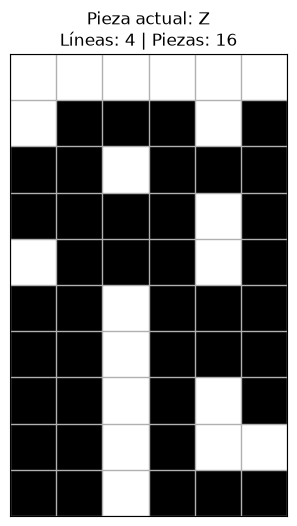

Piezas: 16
Líneas: 4


In [7]:
env = MiniTetrisEnv(
    render_mode="human"
)

state, info = env.reset(seed=2026)

env.render()

for step in range(30):

    valid_actions = np.flatnonzero(
        info["action_mask"]
    )

    if len(valid_actions) == 0:
        break

    action = int(
        env.np_random.choice(
            valid_actions
        )
    )

    state, reward, terminated, truncated, info = env.step(
        action
    )

    env.render()

    if terminated or truncated:
        break


print(
    "Piezas:",
    info["pieces_placed"]
)

print(
    "Líneas:",
    info["lines_cleared"]
)

env.close()

## Pruebas deterministas

### 1. Probar las rotaciones

In [8]:
env = MiniTetrisEnv()
state, info = env.reset(seed=2026)

for piece_name in env.piece_names:

    piece_idx = env.piece_names.index(piece_name)

    print(f"\n===== PIEZA {piece_name} =====")

    for rotation in range(4):

        shape = env._get_rotated_piece(
            piece_idx,
            rotation
        )

        print(f"\nRotación {rotation * 90}°")
        print(shape)


===== PIEZA I =====

Rotación 0°
[[1 1 1 1]]

Rotación 90°
[[1]
 [1]
 [1]
 [1]]

Rotación 180°
[[1 1 1 1]]

Rotación 270°
[[1]
 [1]
 [1]
 [1]]

===== PIEZA O =====

Rotación 0°
[[1 1]
 [1 1]]

Rotación 90°
[[1 1]
 [1 1]]

Rotación 180°
[[1 1]
 [1 1]]

Rotación 270°
[[1 1]
 [1 1]]

===== PIEZA T =====

Rotación 0°
[[1 1 1]
 [0 1 0]]

Rotación 90°
[[0 1]
 [1 1]
 [0 1]]

Rotación 180°
[[0 1 0]
 [1 1 1]]

Rotación 270°
[[1 0]
 [1 1]
 [1 0]]

===== PIEZA S =====

Rotación 0°
[[0 1 1]
 [1 1 0]]

Rotación 90°
[[1 0]
 [1 1]
 [0 1]]

Rotación 180°
[[0 1 1]
 [1 1 0]]

Rotación 270°
[[1 0]
 [1 1]
 [0 1]]

===== PIEZA Z =====

Rotación 0°
[[1 1 0]
 [0 1 1]]

Rotación 90°
[[0 1]
 [1 1]
 [1 0]]

Rotación 180°
[[1 1 0]
 [0 1 1]]

Rotación 270°
[[0 1]
 [1 1]
 [1 0]]

===== PIEZA J =====

Rotación 0°
[[1 0 0]
 [1 1 1]]

Rotación 90°
[[1 1]
 [1 0]
 [1 0]]

Rotación 180°
[[1 1 1]
 [0 0 1]]

Rotación 270°
[[0 1]
 [0 1]
 [1 1]]

===== PIEZA L =====

Rotación 0°
[[0 0 1]
 [1 1 1]]

Rotación 90°
[[1 0]
 [1 

### 2. Probar que acción = rotación + columna

In [9]:
env = MiniTetrisEnv()
env.reset(seed=2026)

for action in range(24):

    rotation = action // env.cols
    column = action % env.cols

    print(
        f"Acción {action:2d} -> "
        f"Rotación {rotation * 90:3d}° | "
        f"Columna {column}"
    )

Acción  0 -> Rotación   0° | Columna 0
Acción  1 -> Rotación   0° | Columna 1
Acción  2 -> Rotación   0° | Columna 2
Acción  3 -> Rotación   0° | Columna 3
Acción  4 -> Rotación   0° | Columna 4
Acción  5 -> Rotación   0° | Columna 5
Acción  6 -> Rotación  90° | Columna 0
Acción  7 -> Rotación  90° | Columna 1
Acción  8 -> Rotación  90° | Columna 2
Acción  9 -> Rotación  90° | Columna 3
Acción 10 -> Rotación  90° | Columna 4
Acción 11 -> Rotación  90° | Columna 5
Acción 12 -> Rotación 180° | Columna 0
Acción 13 -> Rotación 180° | Columna 1
Acción 14 -> Rotación 180° | Columna 2
Acción 15 -> Rotación 180° | Columna 3
Acción 16 -> Rotación 180° | Columna 4
Acción 17 -> Rotación 180° | Columna 5
Acción 18 -> Rotación 270° | Columna 0
Acción 19 -> Rotación 270° | Columna 1
Acción 20 -> Rotación 270° | Columna 2
Acción 21 -> Rotación 270° | Columna 3
Acción 22 -> Rotación 270° | Columna 4
Acción 23 -> Rotación 270° | Columna 5


### 3. Comprobar la máscara de acciones

Vamos a forzar una pieza "I" para revisar las acciones válidas e inválidas

In [10]:
env = MiniTetrisEnv()

state, info = env.reset(seed=2026)

env.current_piece_idx = env.piece_names.index("I")

mask = env.get_action_mask()

for action in range(24):

    rotation = action // env.cols
    column = action % env.cols

    print(
        f"Acción {action:2d} | "
        f"{rotation * 90:3d}° | "
        f"Columna {column} | "
        f"{'VÁLIDA' if mask[action] else 'INVÁLIDA'}"
    )

Acción  0 |   0° | Columna 0 | VÁLIDA
Acción  1 |   0° | Columna 1 | VÁLIDA
Acción  2 |   0° | Columna 2 | VÁLIDA
Acción  3 |   0° | Columna 3 | INVÁLIDA
Acción  4 |   0° | Columna 4 | INVÁLIDA
Acción  5 |   0° | Columna 5 | INVÁLIDA
Acción  6 |  90° | Columna 0 | VÁLIDA
Acción  7 |  90° | Columna 1 | VÁLIDA
Acción  8 |  90° | Columna 2 | VÁLIDA
Acción  9 |  90° | Columna 3 | VÁLIDA
Acción 10 |  90° | Columna 4 | VÁLIDA
Acción 11 |  90° | Columna 5 | VÁLIDA
Acción 12 | 180° | Columna 0 | VÁLIDA
Acción 13 | 180° | Columna 1 | VÁLIDA
Acción 14 | 180° | Columna 2 | VÁLIDA
Acción 15 | 180° | Columna 3 | INVÁLIDA
Acción 16 | 180° | Columna 4 | INVÁLIDA
Acción 17 | 180° | Columna 5 | INVÁLIDA
Acción 18 | 270° | Columna 0 | VÁLIDA
Acción 19 | 270° | Columna 1 | VÁLIDA
Acción 20 | 270° | Columna 2 | VÁLIDA
Acción 21 | 270° | Columna 3 | VÁLIDA
Acción 22 | 270° | Columna 4 | VÁLIDA
Acción 23 | 270° | Columna 5 | VÁLIDA


### 4. Prueba controlada de eliminación de línea

Vamos a crear manualmente en la línea inferior 2 bloques (llenando la celda 0 y 1 de la fila 0), y luego vamos a colocar una pieza "I" horizontal comenzando en la columna 2. Esto debe completar la fila y borrarla.

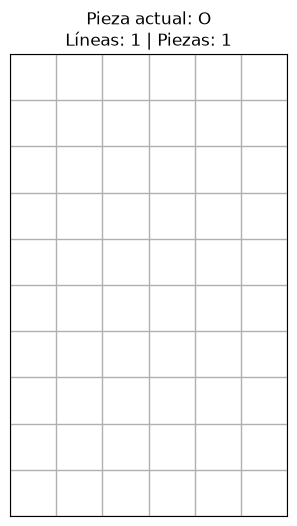

RESULTADO DE LA PRUEBA
----------------------
Reward: 1.0
Líneas eliminadas: 1
Piezas colocadas: 1
Terminated: False
Truncated: False


In [11]:
env = MiniTetrisEnv(
    render_mode="human"
)

state, info = env.reset(seed=2026)

# Limpiar tablero
env.board[:] = 0

# Dejamos 2 bloques en la última fila
env.board[-1, 0] = 1
env.board[-1, 1] = 1

# Forzar pieza I
env.current_piece_idx = env.piece_names.index("I")

# --------------------------------------------------
# Colocar I horizontal desde columna 2
# --------------------------------------------------

rotation = 0
column = 2

action = rotation * env.cols + column

state, reward, terminated, truncated, info = env.step(action)

# Primero renderizamos
env.render()

# DESPUÉS imprimimos resultados
# para que clear_output no los borre
print("RESULTADO DE LA PRUEBA")
print("----------------------")
print("Reward:", reward)
print("Líneas eliminadas:", info["lines_cleared"])
print("Piezas colocadas:", info["pieces_placed"])
print("Terminated:", terminated)
print("Truncated:", truncated)

### 5. Comprobar truncated = True en 300 piezas

Creamos un entorno con max_pieces =300 y simulamos que ya lleva 299.

In [12]:
env = MiniTetrisEnv(
    max_pieces=300
)

state, info = env.reset(seed=2026)

# Tablero vacío para evitar Game Over
env.board[:] = 0

# Simulamos que ya sobrevivió 299 piezas
env.pieces_placed = 299

# Forzamos una pieza O
env.current_piece_idx = env.piece_names.index("O")

valid_actions = np.flatnonzero(
    env.get_action_mask()
)

action = int(valid_actions[0])

state, reward, terminated, truncated, info = env.step(
    action
)

print("Piezas:", info["pieces_placed"])
print("Terminated:", terminated)
print("Truncated:", truncated)
print(
    "Reached piece limit:",
    info["reached_piece_limit"]
)

Piezas: 300
Terminated: False
Truncated: True
Reached piece limit: True


### 6. Prueba para seed

Comprobamos que la semilla realmente da reproducibilidad

In [13]:
env1 = MiniTetrisEnv()
env2 = MiniTetrisEnv()

state1, info1 = env1.reset(seed=2026)
state2, info2 = env2.reset(seed=2026)

print("Env 1:", info1["piece"])
print("Env 2:", info2["piece"])

print(
    "Estados iguales:",
    np.array_equal(state1, state2)
)

Env 1: J
Env 2: J
Estados iguales: True


### 7. Comprobar la terminación natural del juego al perder

In [14]:
env = MiniTetrisEnv(
    max_pieces=300
)

state, info = env.reset(seed=2026)

# Limpiar tablero
env.board[:] = 0

# --------------------------------------------------
# Crear una zona superior casi bloqueada
# --------------------------------------------------

# Filas pares
env.board[0, [2, 4]] = 1
env.board[2, [2, 4]] = 1

# Filas impares
env.board[1, [1, 3, 5]] = 1
env.board[3, [1, 3, 5]] = 1

# Este bloque hace que la pieza I vertical
# se detenga en la parte superior
env.board[4, 0] = 1

# --------------------------------------------------
# Forzar pieza I
# --------------------------------------------------

env.current_piece_idx = env.piece_names.index("I")

# Rotación 90° -> I vertical
# Columna 0
rotation = 1
column = 0

action = rotation * env.cols + column

# Comprobar que ESTA acción sí es válida
print(
    "Acción final válida:",
    env.get_action_mask()[action]
)

# --------------------------------------------------
# Ejecutar última colocación
# --------------------------------------------------

state, reward, terminated, truncated, info = env.step(action)

print("\nRESULTADO PRUEBA TERMINATED")
print("---------------------------")
print("Siguiente pieza:", info["piece"])
print("Piezas colocadas:", info["pieces_placed"])
print("Reward:", reward)
print("Acciones válidas restantes:", info["action_mask"].sum())
print("Terminated:", terminated)
print("Truncated:", truncated)
print(
    "Reached piece limit:",
    info["reached_piece_limit"]
)

Acción final válida: True

RESULTADO PRUEBA TERMINATED
---------------------------
Siguiente pieza: O
Piezas colocadas: 1
Reward: -1.0
Acciones válidas restantes: 0
Terminated: True
Truncated: False
Reached piece limit: False


# Entrenamiento DQN

Pasos terminados y siguientes pasos:

0. MiniTetris validado ✅
        ↓
1. Configurar PyTorch y dispositivo
        ↓
2. Crear QNetwork
   67 → 128 → 128 → 24
        ↓
3. Crear ReplayBuffer
        ↓
4. Implementar ε-greedy + action mask
        ↓
5. Implementar una actualización DQN
        ↓
6. Hacer entrenamiento MUY corto
        ↓
7. Verificar que la loss, pesos y buffer cambian
        ↓
8. Recién entonces entrenar en serio

## Instalaciones e importaciones

### Instalaciones

In [15]:
!pip install torch -q

### Importaciones

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

import random
from collections import deque

## Configuración general y seed

In [17]:
SEED = 2026

STATE_SIZE = 67
ACTION_SIZE = 24

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", device)

Dispositivo: cpu


## Crear la red Q

Arquitectura:

Tablero + pieza
67 valores

      ↓

Linear(67,128)

      ↓

ReLU

      ↓

Linear(128,128)

      ↓

ReLU

      ↓

Linear(128,24)

      ↓

24 Q-values  --> Cada una de estas 24 salidas corresponde a: rotación + columna

#### Crearla

In [18]:
class QNetwork(nn.Module):

    def __init__(
        self,
        state_size=67,
        action_size=24
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                state_size,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                action_size
            )
        )

    def forward(self, state):

        return self.network(state)

#### Probarla

Probamos que realmente quedó con la arquitectura definida.

In [19]:
q_network = QNetwork(
    STATE_SIZE,
    ACTION_SIZE
).to(device)

print(q_network)

QNetwork(
  (network): Sequential(
    (0): Linear(in_features=67, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=24, bias=True)
  )
)


#### Darle un estado real de MiniTetris

Probamos la red con un estado real de nuestro entorno

- Creamos el estado

In [20]:
env = MiniTetrisEnv(
    max_pieces=300
)

state, info = env.reset(
    seed=SEED
)

state_tensor = torch.tensor(
    state,
    dtype=torch.float32,
    device=device
).unsqueeze(0)

print(
    "Forma del estado:",
    state_tensor.shape
)

Forma del estado: torch.Size([1, 67])


- Pasamos el estado por la red

In [21]:
with torch.no_grad():

    q_values = q_network(
        state_tensor
    )

print(
    "Forma de la salida:",
    q_values.shape
)

print("\nQ-values:")
print(q_values)

Forma de la salida: torch.Size([1, 24])

Q-values:
tensor([[ 0.0307, -0.0160, -0.0312, -0.0053, -0.1315,  0.0735,  0.0666,  0.0541,
         -0.0584,  0.0061,  0.0750,  0.0479, -0.0025, -0.0381,  0.0466, -0.0285,
          0.0128, -0.0090, -0.0307, -0.0582,  0.0482, -0.0058, -0.0626,  0.0494]])


## Replay Buffer

El replay buffer es como una memoria que guarda transiciones y permite tomar mini-lotes aleatorios, rompiendo la correlación temporal entre experiencias consecutivas.

Nuestro buffer tendrá una pequeña adaptación.

Además de:

(s,a,r,s′)

guardaremos:

terminated
truncated
next_action_mask

#### Crearlo

In [22]:
class ReplayBuffer:

    def __init__(
        self,
        capacity
    ):

        self.buffer = deque(
            maxlen=capacity
        )

    def add(
        self,
        state,
        action,
        reward,
        next_state,
        terminated,
        truncated,
        next_action_mask
    ):

        self.buffer.append(
            (
                state.copy(),
                int(action),
                float(reward),
                next_state.copy(),
                bool(terminated),
                bool(truncated),
                next_action_mask.copy()
            )
        )

    def sample(
        self,
        batch_size
    ):

        batch = random.sample(
            self.buffer,
            batch_size
        )

        (
            states,
            actions,
            rewards,
            next_states,
            terminated,
            truncated,
            next_action_masks
        ) = zip(*batch)

        states = torch.tensor(
            np.array(states),
            dtype=torch.float32,
            device=device
        )

        actions = torch.tensor(
            actions,
            dtype=torch.long,
            device=device
        )

        rewards = torch.tensor(
            rewards,
            dtype=torch.float32,
            device=device
        )

        next_states = torch.tensor(
            np.array(next_states),
            dtype=torch.float32,
            device=device
        )

        terminated = torch.tensor(
            terminated,
            dtype=torch.float32,
            device=device
        )

        truncated = torch.tensor(
            truncated,
            dtype=torch.float32,
            device=device
        )

        next_action_masks = torch.tensor(
            np.array(next_action_masks),
            dtype=torch.bool,
            device=device
        )

        return (
            states,
            actions,
            rewards,
            next_states,
            terminated,
            truncated,
            next_action_masks
        )

    def __len__(self):

        return len(self.buffer)

#### Crear la memoria

In [23]:
BUFFER_SIZE = 20_000

replay_buffer = ReplayBuffer(
    capacity=BUFFER_SIZE
)

print(
    "Experiencias guardadas:",
    len(replay_buffer)
)

Experiencias guardadas: 0


#### Llenarlo con algunas experiencias aleatorias

Jugamos aleatoriamente

In [24]:
env = MiniTetrisEnv(
    max_pieces=300
)

state, info = env.reset(
    seed=SEED
)

for step in range(20):

    valid_actions = np.flatnonzero(
        info["action_mask"]
    )

    if len(valid_actions) == 0:
        break

    action = int(
        env.np_random.choice(
            valid_actions
        )
    )

    next_state, reward, terminated, truncated, next_info = env.step(
        action
    )

    replay_buffer.add(
        state=state,
        action=action,
        reward=reward,
        next_state=next_state,
        terminated=terminated,
        truncated=truncated,
        next_action_mask=next_info["action_mask"]
    )

    state = next_state
    info = next_info

    if terminated or truncated:
        break


print(
    "Experiencias guardadas:",
    len(replay_buffer)
)

Experiencias guardadas: 16


#### Inspeccionar una experiencia

Observamos explícitamente qué está guardando DQN

In [25]:
experience = replay_buffer.buffer[0]

(
    stored_state,
    stored_action,
    stored_reward,
    stored_next_state,
    stored_terminated,
    stored_truncated,
    stored_next_mask
) = experience


print(
    "State:",
    stored_state.shape
)

print(
    "Action:",
    stored_action
)

print(
    "Reward:",
    stored_reward
)

print(
    "Next state:",
    stored_next_state.shape
)

print(
    "Terminated:",
    stored_terminated
)

print(
    "Truncated:",
    stored_truncated
)

print(
    "Acciones válidas siguientes:",
    stored_next_mask.sum()
)

State: (67,)
Action: 3
Reward: 0.0
Next state: (67,)
Terminated: False
Truncated: False
Acciones válidas siguientes: 18


#### Probar un mini-batch

Debemos verificar que el replay buffer puede producir lotes correctamente.

In [26]:
BATCH_SIZE_TEST = 4

batch = replay_buffer.sample(
    BATCH_SIZE_TEST
)

(
    states,
    actions,
    rewards,
    next_states,
    terminated,
    truncated,
    next_action_masks
) = batch


print(
    "States:",
    states.shape
)

print(
    "Actions:",
    actions.shape
)

print(
    "Rewards:",
    rewards.shape
)

print(
    "Next states:",
    next_states.shape
)

print(
    "Terminated:",
    terminated.shape
)

print(
    "Truncated:",
    truncated.shape
)

print(
    "Next action masks:",
    next_action_masks.shape
)

States: torch.Size([4, 67])
Actions: torch.Size([4])
Rewards: torch.Size([4])
Next states: torch.Size([4, 67])
Terminated: torch.Size([4])
Truncated: torch.Size([4])
Next action masks: torch.Size([4, 24])


## Red online y red objetivo

Vamos a empezar desde redes nuevas para no mezclar esta prueba con la red que usamos antes.

ONLINE NETWORK

      │
      ├── se actualiza con gradiente
      │
      
TARGET NETWORK

      │
      └── permanece congelada
          y se sincroniza periódicamente

#### Crear las redes

In [27]:
SEED = 2026

torch.manual_seed(SEED)

online_network = QNetwork(
    STATE_SIZE,
    ACTION_SIZE
).to(device)

target_network = QNetwork(
    STATE_SIZE,
    ACTION_SIZE
).to(device)

# La target empieza exactamente con los mismos pesos
target_network.load_state_dict(
    online_network.state_dict()
)

# La target no se entrena mediante backpropagation
target_network.eval()

print("Red online creada ✅")
print("Red target creada ✅")

Red online creada ✅
Red target creada ✅


#### Verificar que inicialmente son idénticas

In [28]:
same_parameters = all(
    torch.equal(
        online_param,
        target_param
    )
    for online_param, target_param
    in zip(
        online_network.parameters(),
        target_network.parameters()
    )
)

print(
    "¿Online y target empiezan iguales?",
    same_parameters
)

¿Online y target empiezan iguales? True


## Crear optimizador

Para esta primera prueba técnica usaremos:

In [29]:
LEARNING_RATE = 1e-3
GAMMA = 0.99

No los estamos declarando como hiperparámetros definitivos del experimento. Son valores iniciales para comprobar que todo funciona.

In [30]:
optimizer = optim.Adam(
    online_network.parameters(),
    lr=LEARNING_RATE
)

loss_function = nn.MSELoss()

Usamos MSE porque es precisamente la pérdida cuadrática mostrada en las diapositivas:

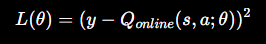

## Implementar ε-greedy con máscara

Ahora necesitamos que el agente pueda escoger acciones.

In [31]:
def select_action(
    state,
    action_mask,
    epsilon,
    network,
    rng
):

    valid_actions = np.flatnonzero(
        action_mask
    )

    if len(valid_actions) == 0:
        raise ValueError(
            "No hay acciones válidas disponibles."
        )

    # -----------------------------------------
    # EXPLORACIÓN
    # -----------------------------------------

    if rng.random() < epsilon:

        action = int(
            rng.choice(valid_actions)
        )

        return action

    # -----------------------------------------
    # EXPLOTACIÓN
    # -----------------------------------------

    state_tensor = torch.tensor(
        state,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():

        q_values = network(
            state_tensor
        )[0]

    mask_tensor = torch.tensor(
        action_mask,
        dtype=torch.bool,
        device=device
    )

    # Acciones imposibles reciben -infinito
    masked_q_values = q_values.masked_fill(
        ~mask_tensor,
        float("-inf")
    )

    action = int(
        torch.argmax(
            masked_q_values
        ).item()
    )

    return action

La lógica queda:

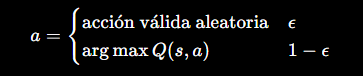

pero con nuestra adaptación:

El argmax solo considera colocaciones físicamente válidas.

#### Probar ε-greedy

Primero creamos un generador reproducible:

In [32]:
rng = np.random.default_rng(
    SEED
)

env = MiniTetrisEnv(
    max_pieces=300
)

state, info = env.reset(
    seed=SEED
)

Exploración total:

In [33]:
epsilon = 1.0

SIEMPRE debe explorar

In [34]:
print("ε = 1.0")

for i in range(5):

    action = select_action(
        state,
        info["action_mask"],
        epsilon=1.0,
        network=online_network,
        rng=rng
    )

    rotation = action // env.cols
    column = action % env.cols

    print(
        f"Acción {action:2d} -> "
        f"{rotation * 90:3d}° | "
        f"columna {column}"
    )

ε = 1.0
Acción  0 ->   0° | columna 0
Acción 14 -> 180° | columna 2
Acción 14 -> 180° | columna 2
Acción  8 ->  90° | columna 2
Acción 15 -> 180° | columna 3


Explotación total

SIEMPRE debe explotar

In [35]:
print("\nε = 0.0")

for i in range(5):

    action = select_action(
        state,
        info["action_mask"],
        epsilon=0.0,
        network=online_network,
        rng=rng
    )

    print("Acción greedy:", action)


ε = 0.0
Acción greedy: 10
Acción greedy: 10
Acción greedy: 10
Acción greedy: 10
Acción greedy: 10


Como el estado y la red no cambian, debería escoger la misma acción greedy las cinco veces.

Eso confirma que nuestra función separa correctamente exploración y explotación.

## Implementar UNA actualización DQN

Para cada experiencia del minibatch tenemos:

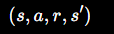

La online network produce:



La target network produce:

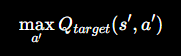

y construimos (sí no terminó):

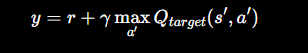

Si el juego realmente terminó:

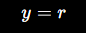

Después calculamos:

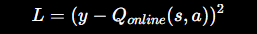

y hacemos:

loss

 ↓

backpropagation

 ↓

optimizer.step()

 ↓
 
cambian los pesos de la ONLINE NETWORK

In [36]:
def train_step(
    replay_buffer,
    online_network,
    target_network,
    optimizer,
    batch_size,
    gamma
):

    # No entrenar si todavía no hay
    # suficientes experiencias
    if len(replay_buffer) < batch_size:
        return None

    (
        states,
        actions,
        rewards,
        next_states,
        terminated,
        truncated,
        next_action_masks
    ) = replay_buffer.sample(
        batch_size
    )

    # =====================================================
    # 1. Q(s,a) predicho por la ONLINE NETWORK
    # =====================================================

    all_q_values = online_network(
        states
    )

    # Elegir únicamente Q(s,a) de la acción
    # realmente ejecutada
    predicted_q = all_q_values.gather(
        1,
        actions.unsqueeze(1)
    ).squeeze(1)

    # =====================================================
    # 2. Calcular max Q_target(s', a')
    # =====================================================

    with torch.no_grad():

        next_q_values = target_network(
            next_states
        )

        # Ignorar acciones imposibles
        masked_next_q_values = (
            next_q_values.masked_fill(
                ~next_action_masks,
                float("-inf")
            )
        )

        max_next_q = (
            masked_next_q_values
            .max(dim=1)
            .values
        )

        # Si realmente terminó el juego,
        # no existe futuro sobre el cual hacer bootstrap.
        max_next_q = torch.where(
            terminated.bool(),
            torch.zeros_like(max_next_q),
            max_next_q
        )

        # =================================================
        # 3. Target TD
        # =================================================

        target_q = (
            rewards
            + gamma
            * (1.0 - terminated)
            * max_next_q
        )

    # =====================================================
    # 4. Loss
    # =====================================================

    loss = loss_function(
        predicted_q,
        target_q
    )

    # =====================================================
    # 5. Backpropagation
    # =====================================================

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    return float(
        loss.item()
    )

### Comprobar que la red online cambia

Primero guardamos una copia exacta de los pesos antes del entrenamiento:

In [37]:
online_before = {
    name: parameter.detach().clone()
    for name, parameter
    in online_network.state_dict().items()
}

target_before = {
    name: parameter.detach().clone()
    for name, parameter
    in target_network.state_dict().items()
}

Ahora hacemos una sola actualización:

In [38]:
TEST_BATCH_SIZE = 4

loss = train_step(
    replay_buffer=replay_buffer,
    online_network=online_network,
    target_network=target_network,
    optimizer=optimizer,
    batch_size=TEST_BATCH_SIZE,
    gamma=GAMMA
)

print(
    "Loss después de una actualización:",
    loss
)

Loss después de una actualización: 0.4818997085094452


### Verificar que ONLINE cambió

In [39]:
online_changed = any(
    not torch.equal(
        online_before[name],
        parameter
    )
    for name, parameter
    in online_network.state_dict().items()
)

print(
    "¿Cambió la red online?",
    online_changed
)

¿Cambió la red online? True


Eso significa que por primera vez nuestra red acaba de aprender de una experiencia del MiniTetris.

Todavía prácticamente nada útil, pero matemáticamente ya ocurrió una actualización DQN.

### Verificar que TARGET NO cambió

In [40]:
target_changed = any(
    not torch.equal(
        target_before[name],
        parameter
    )
    for name, parameter
    in target_network.state_dict().items()
)

print(
    "¿Cambió la red target?",
    target_changed
)

¿Cambió la red target? False


Tenemos ahora:

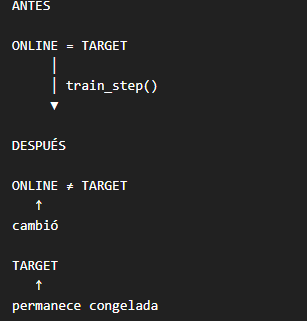

### Verificar que ahora son diferentes

In [41]:
still_equal = all(
    torch.equal(
        online_param,
        target_param
    )
    for online_param, target_param
    in zip(
        online_network.parameters(),
        target_network.parameters()
    )
)

print(
    "¿Online y target siguen iguales?",
    still_equal
)

¿Online y target siguen iguales? False


### Sincronizar manualmente la target

Después de cierto número de pasos, DQN hace:



Hagámoslo manualmente:

In [42]:
target_network.load_state_dict(
    online_network.state_dict()
)

<All keys matched successfully>

Y comprobamos:

In [43]:
same_again = all(
    torch.equal(
        online_param,
        target_param
    )
    for online_param, target_param
    in zip(
        online_network.parameters(),
        target_network.parameters()
    )
)

print(
    "¿Iguales después de sincronizar?",
    same_again
)

¿Iguales después de sincronizar? True


Lo que acabamos de validar:

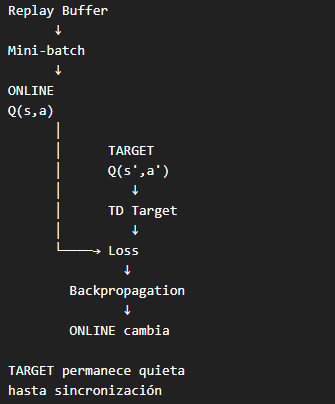



## Reiniciar TODO antes del entrenamiento

Importante: como nuestra red anterior recibió una actualización de prueba, vamos a crear todo nuevamente desde cero.

In [44]:
# ============================================================
# CONFIGURACIÓN DEL ENTRENAMIENTO PILOTO
# ============================================================

SEED = 2026

STATE_SIZE = 67
ACTION_SIZE = 24

GAMMA = 0.99
LEARNING_RATE = 1e-3

BUFFER_SIZE = 20_000
BATCH_SIZE = 64

LEARNING_STARTS = 500

TARGET_UPDATE_FREQ = 250

EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 5_000

PILOT_EPISODES = 150
MAX_PIECES = 300


# ============================================================
# SEEDS
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# ENTORNO
# ============================================================

env = MiniTetrisEnv(
    render_mode=None,
    max_pieces=MAX_PIECES
)


# ============================================================
# RED ONLINE
# ============================================================

online_network = QNetwork(
    STATE_SIZE,
    ACTION_SIZE
).to(device)


# ============================================================
# RED TARGET
# ============================================================

target_network = QNetwork(
    STATE_SIZE,
    ACTION_SIZE
).to(device)

target_network.load_state_dict(
    online_network.state_dict()
)

target_network.eval()


# ============================================================
# OPTIMIZADOR
# ============================================================

optimizer = optim.Adam(
    online_network.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# REPLAY BUFFER
# ============================================================

replay_buffer = ReplayBuffer(
    capacity=BUFFER_SIZE
)


# ============================================================
# RNG PARA EPSILON-GREEDY
# ============================================================

rng = np.random.default_rng(SEED)


print("Entrenamiento reiniciado ✅")
print("Dispositivo:", device)

Entrenamiento reiniciado ✅
Dispositivo: cpu


## Decaimiento de ε

Vamos a hacer que ε baje linealmente según los pasos del agente.

In [45]:
def get_epsilon(step):

    fraction = min(
        step / EPS_DECAY_STEPS,
        1.0
    )

    epsilon = (
        EPS_START
        + fraction
        * (EPS_END - EPS_START)
    )

    return epsilon

Así:

Paso 0
ε = 1.00
→ prácticamente todo exploración

↓

Paso 2500
ε ≈ 0.525

↓

Paso 5000
ε = 0.05
→ principalmente explotación

Esto no lo estamos declarando todavía como configuración definitiva. Primero queremos observar qué pasa.

## Variables para guardar métricas

No vamos a mirar solamente reward.

Guardaremos:

- recompensa por episodio;
- líneas eliminadas;
- piezas sobrevividas;
- pérdida;
- ε;
- si alcanzó las 300 piezas.

In [46]:
episode_rewards = []
episode_lines = []
episode_pieces = []
episode_epsilons = []
loss_history = []
reached_limit_history = []

global_step = 0

# Primer entrenamiento DQN completo (Piloto)

In [ ]:
for episode in range(PILOT_EPISODES):

    # ========================================================
    # RESET
    # ========================================================

    # Solo inicializamos la secuencia aleatoria
    # con 2026 en el primer episodio.
    #
    # En los siguientes usamos seed=None para que
    # el generador continúe su secuencia en vez de
    # repetir exactamente las mismas piezas.

    if episode == 0:
        state, info = env.reset(seed=SEED)
    else:
        state, info = env.reset()

    episode_reward = 0.0
    episode_losses = []

    terminated = False
    truncated = False

    # ========================================================
    # EPISODIO
    # ========================================================

    while not (terminated or truncated):

        # ----------------------------------------------------
        # ε actual
        # ----------------------------------------------------

        epsilon = get_epsilon(
            global_step
        )

        # ----------------------------------------------------
        # Elegir acción
        # ----------------------------------------------------

        action = select_action(
            state=state,
            action_mask=info["action_mask"],
            epsilon=epsilon,
            network=online_network,
            rng=rng
        )

        # ----------------------------------------------------
        # Ejecutar acción
        # ----------------------------------------------------

        (
            next_state,
            reward,
            terminated,
            truncated,
            next_info
        ) = env.step(action)

        # ----------------------------------------------------
        # Guardar experiencia
        # ----------------------------------------------------

        replay_buffer.add(
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
            terminated=terminated,
            truncated=truncated,
            next_action_mask=next_info["action_mask"]
        )

        # ----------------------------------------------------
        # Entrenar
        # ----------------------------------------------------

        if len(replay_buffer) >= LEARNING_STARTS:

            loss = train_step(
                replay_buffer=replay_buffer,
                online_network=online_network,
                target_network=target_network,
                optimizer=optimizer,
                batch_size=BATCH_SIZE,
                gamma=GAMMA
            )

            if loss is not None:

                episode_losses.append(
                    loss
                )

                loss_history.append(
                    loss
                )

        # ----------------------------------------------------
        # Actualizar TARGET NETWORK
        # ----------------------------------------------------

        if (
            global_step > 0
            and global_step % TARGET_UPDATE_FREQ == 0
        ):

            target_network.load_state_dict(
                online_network.state_dict()
            )

        # ----------------------------------------------------
        # Avanzar
        # ----------------------------------------------------

        state = next_state
        info = next_info

        episode_reward += reward

        global_step += 1

    # ========================================================
    # FIN DEL EPISODIO
    # ========================================================

    episode_rewards.append(
        episode_reward
    )

    episode_lines.append(
        info["lines_cleared"]
    )

    episode_pieces.append(
        info["pieces_placed"]
    )

    episode_epsilons.append(
        epsilon
    )

    reached_limit_history.append(
        info["reached_piece_limit"]
    )

    # ========================================================
    # MOSTRAR PROGRESO
    # ========================================================

    if (
        (episode + 1) % 10 == 0
        or episode == 0
    ):

        recent_rewards = episode_rewards[-10:]
        recent_lines = episode_lines[-10:]
        recent_pieces = episode_pieces[-10:]

        mean_loss = (
            np.mean(episode_losses)
            if len(episode_losses) > 0
            else np.nan
        )

        print(
            f"Episodio {episode + 1:3d}/{PILOT_EPISODES} | "
            f"ε={epsilon:.3f} | "
            f"Reward={episode_reward:6.1f} | "
            f"Líneas={info['lines_cleared']:3d} | "
            f"Piezas={info['pieces_placed']:3d} | "
            f"Prom.R10={np.mean(recent_rewards):6.2f} | "
            f"Prom.L10={np.mean(recent_lines):5.2f} | "
            f"Prom.P10={np.mean(recent_pieces):6.2f} | "
            f"Loss={mean_loss:.5f}"
        )

Episodio   1/150 | ε=0.999 | Reward=   0.0 | Líneas=  1 | Piezas=  8 | Prom.R10=  0.00 | Prom.L10= 1.00 | Prom.P10=  8.00 | Loss=nan
Episodio  10/150 | ε=0.984 | Reward=  -1.0 | Líneas=  0 | Piezas=  8 | Prom.R10= -0.40 | Prom.L10= 0.50 | Prom.P10=  8.50 | Loss=nan
Episodio  20/150 | ε=0.967 | Reward=   0.0 | Líneas=  1 | Piezas=  9 | Prom.R10= -0.50 | Prom.L10= 0.50 | Prom.P10=  9.20 | Loss=nan
Episodio  30/150 | ε=0.949 | Reward=  -1.0 | Líneas=  0 | Piezas=  8 | Prom.R10= -0.20 | Prom.L10= 0.70 | Prom.P10=  9.00 | Loss=nan
Episodio  40/150 | ε=0.931 | Reward=   0.0 | Líneas=  1 | Piezas= 10 | Prom.R10= -0.30 | Prom.L10= 0.70 | Prom.P10=  9.70 | Loss=nan
Episodio  50/150 | ε=0.913 | Reward=  -1.0 | Líneas=  0 | Piezas=  7 | Prom.R10=  0.10 | Prom.L10= 0.90 | Prom.P10=  9.50 | Loss=nan
Episodio  60/150 | ε=0.896 | Reward=  -1.0 | Líneas=  0 | Piezas=  9 | Prom.R10= -0.60 | Prom.L10= 0.40 | Prom.P10=  8.70 | Loss=0.15515
Episodio  70/150 | ε=0.880 | Reward=  -1.0 | Líneas=  0 | Piezas=

## Imprimir resumen

In [48]:
print("\n" + "=" * 55)
print("RESULTADOS DEL ENTRENAMIENTO PILOTO")
print("=" * 55)

print(
    "Episodios:",
    len(episode_rewards)
)

print(
    "Pasos totales:",
    global_step
)

print(
    "Experiencias en replay buffer:",
    len(replay_buffer)
)

print(
    "ε final:",
    round(episode_epsilons[-1], 4)
)

print(
    "Reward promedio últimos 20:",
    round(
        np.mean(episode_rewards[-20:]),
        2
    )
)

print(
    "Líneas promedio últimos 20:",
    round(
        np.mean(episode_lines[-20:]),
        2
    )
)

print(
    "Piezas promedio últimos 20:",
    round(
        np.mean(episode_pieces[-20:]),
        2
    )
)

print(
    "Máximo de líneas:",
    max(episode_lines)
)

print(
    "Máximo de piezas:",
    max(episode_pieces)
)

print(
    "Veces que alcanzó 300 piezas:",
    sum(reached_limit_history)
)


RESULTADOS DEL ENTRENAMIENTO PILOTO
Episodios: 150
Pasos totales: 1402
Experiencias en replay buffer: 1402
ε final: 0.7338
Reward promedio últimos 20: -0.4
Líneas promedio últimos 20: 0.6
Piezas promedio últimos 20: 9.4
Máximo de líneas: 6
Máximo de piezas: 19
Veces que alcanzó 300 piezas: 0


## Primera gráfica: Recompensa

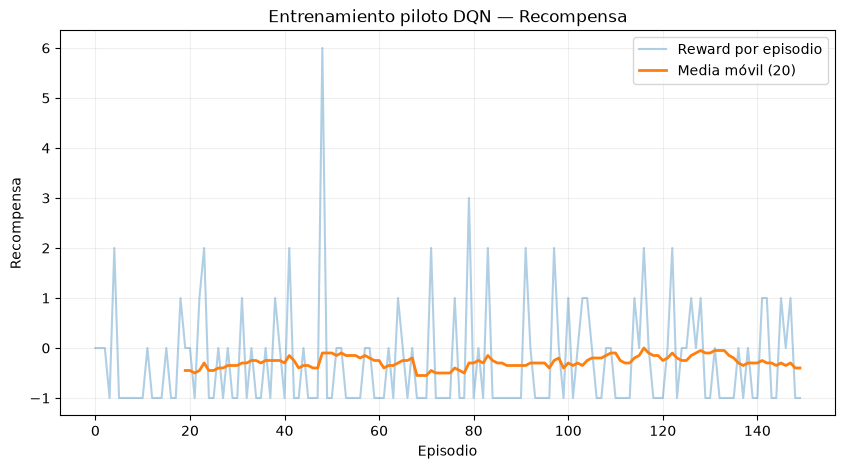

In [49]:
window = 20

reward_moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    episode_rewards,
    alpha=0.35,
    label="Reward por episodio"
)

plt.plot(
    range(
        window - 1,
        len(episode_rewards)
    ),
    reward_moving_average,
    linewidth=2,
    label="Media móvil (20)"
)

plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.title("Entrenamiento piloto DQN — Recompensa")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

## Segunda gráfica: líneas eliminadas

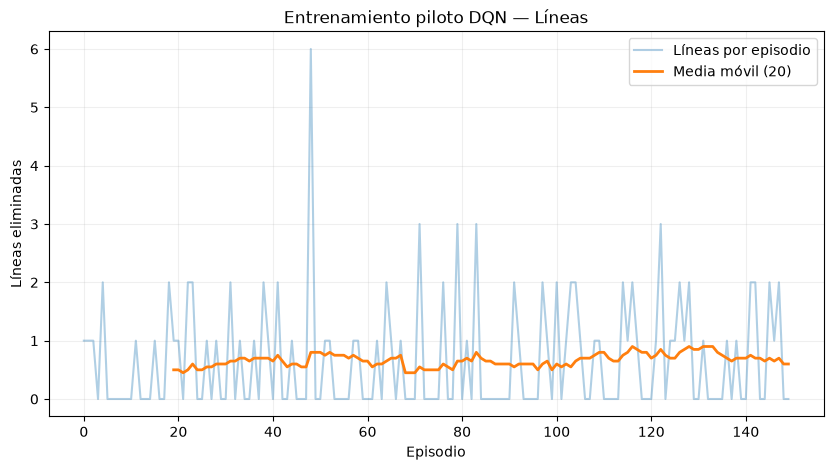

In [50]:
lines_moving_average = np.convolve(
    episode_lines,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    episode_lines,
    alpha=0.35,
    label="Líneas por episodio"
)

plt.plot(
    range(
        window - 1,
        len(episode_lines)
    ),
    lines_moving_average,
    linewidth=2,
    label="Media móvil (20)"
)

plt.xlabel("Episodio")
plt.ylabel("Líneas eliminadas")
plt.title("Entrenamiento piloto DQN — Líneas")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

## Tercera gráfica: piezas sobrevividas

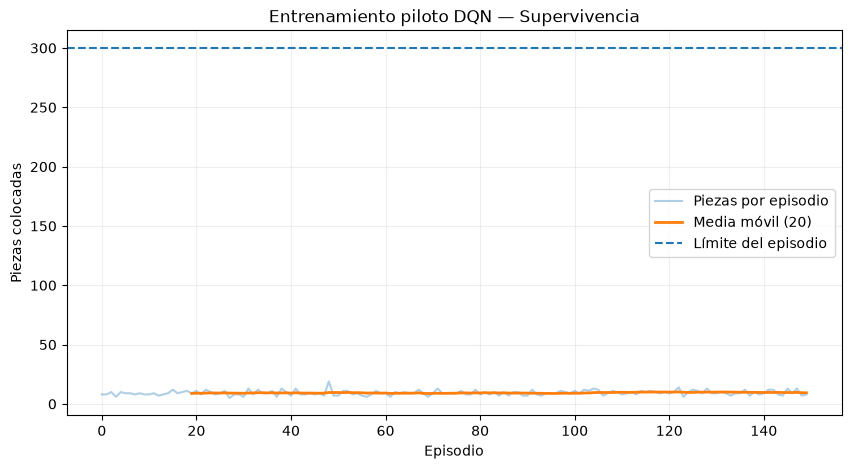

In [51]:
pieces_moving_average = np.convolve(
    episode_pieces,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    episode_pieces,
    alpha=0.35,
    label="Piezas por episodio"
)

plt.plot(
    range(
        window - 1,
        len(episode_pieces)
    ),
    pieces_moving_average,
    linewidth=2,
    label="Media móvil (20)"
)

plt.axhline(
    y=300,
    linestyle="--",
    label="Límite del episodio"
)

plt.xlabel("Episodio")
plt.ylabel("Piezas colocadas")
plt.title("Entrenamiento piloto DQN — Supervivencia")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

# Entrenamiento real DQN — MiniTetris
## Corrida principal — Seed 2026

Después de validar el entorno, los componentes de DQN y realizar un entrenamiento piloto de 150 episodios, se reinicializa completamente el agente para realizar el entrenamiento principal desde cero.

El entrenamiento piloto se conserva como evidencia del proceso de desarrollo y validación.

## Configuración del entrenamiento real

In [52]:
# ============================================================
# ENTRENAMIENTO REAL — CONFIGURACIÓN
# ============================================================

REAL_SEED = 2026

REAL_TRAIN_EPISODES = 2000

REAL_STATE_SIZE = 67
REAL_ACTION_SIZE = 24

REAL_GAMMA = 0.99
REAL_LEARNING_RATE = 1e-3

REAL_BUFFER_SIZE = 20_000
REAL_BATCH_SIZE = 64
REAL_LEARNING_STARTS = 500

REAL_TARGET_UPDATE_FREQ = 250

REAL_EPS_START = 1.0
REAL_EPS_END = 0.05
REAL_EPS_DECAY_STEPS = 5_000

REAL_MAX_PIECES = 300

print("Configuración del entrenamiento real ✅")
print("Episodios:", REAL_TRAIN_EPISODES)
print("Seed:", REAL_SEED)
print("Dispositivo:", device)

Configuración del entrenamiento real ✅
Episodios: 2000
Seed: 2026
Dispositivo: cpu


## Reiniciar TODA la aleatoriedad

In [53]:
# ============================================================
# REINICIO DE SEEDS
# ============================================================

random.seed(REAL_SEED)
np.random.seed(REAL_SEED)
torch.manual_seed(REAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(REAL_SEED)

print("Seeds reiniciadas ✅")

Seeds reiniciadas ✅


## Crear entorno, redes, optimizador y buffer NUEVOS

In [54]:
# ============================================================
# ENTORNO REAL
# ============================================================

real_env = MiniTetrisEnv(
    render_mode=None,
    max_pieces=REAL_MAX_PIECES
)


# ============================================================
# ONLINE NETWORK
# ============================================================

real_online_network = QNetwork(
    REAL_STATE_SIZE,
    REAL_ACTION_SIZE
).to(device)


# ============================================================
# TARGET NETWORK
# ============================================================

real_target_network = QNetwork(
    REAL_STATE_SIZE,
    REAL_ACTION_SIZE
).to(device)

real_target_network.load_state_dict(
    real_online_network.state_dict()
)

real_target_network.eval()


# ============================================================
# OPTIMIZADOR
# ============================================================

real_optimizer = optim.Adam(
    real_online_network.parameters(),
    lr=REAL_LEARNING_RATE
)


# ============================================================
# REPLAY BUFFER
# ============================================================

real_replay_buffer = ReplayBuffer(
    capacity=REAL_BUFFER_SIZE
)


# ============================================================
# RNG DE EXPLORACIÓN
# ============================================================

real_rng = np.random.default_rng(
    REAL_SEED
)


print("Entorno nuevo ✅")
print("Online Network nueva ✅")
print("Target Network nueva ✅")
print("Optimizador nuevo ✅")
print("Replay Buffer vacío ✅")
print(
    "Experiencias:",
    len(real_replay_buffer)
)

Entorno nuevo ✅
Online Network nueva ✅
Target Network nueva ✅
Optimizador nuevo ✅
Replay Buffer vacío ✅
Experiencias: 0


## ε del entrenamiento real

In [55]:
def get_real_epsilon(step):

    fraction = min(
        step / REAL_EPS_DECAY_STEPS,
        1.0
    )

    epsilon = (
        REAL_EPS_START
        + fraction
        * (
            REAL_EPS_END
            - REAL_EPS_START
        )
    )

    return epsilon

Verifiquemos

In [56]:
print("ε paso 0:   ", get_real_epsilon(0))
print("ε paso 2500:", get_real_epsilon(2500))
print("ε paso 5000:", get_real_epsilon(5000))
print("ε paso 8000:", get_real_epsilon(8000))

ε paso 0:    1.0
ε paso 2500: 0.525
ε paso 5000: 0.050000000000000044
ε paso 8000: 0.050000000000000044


## Métricas NUEVAS

In [57]:
# ============================================================
# MÉTRICAS DEL ENTRENAMIENTO REAL
# ============================================================

real_episode_rewards = []
real_episode_lines = []
real_episode_pieces = []
real_episode_epsilons = []
real_episode_mean_losses = []

real_loss_history = []
real_reached_limit_history = []

real_global_step = 0

## Entrenamiento REAL

In [58]:
# ============================================================
# ENTRENAMIENTO REAL
# ============================================================

training_start_time = time.perf_counter()

for episode in range(REAL_TRAIN_EPISODES):

    # --------------------------------------------------------
    # RESET DEL EPISODIO
    # --------------------------------------------------------

    if episode == 0:

        state, info = real_env.reset(
            seed=REAL_SEED
        )

    else:

        state, info = real_env.reset()

    episode_reward = 0.0
    episode_losses = []

    terminated = False
    truncated = False

    # ========================================================
    # LOOP DEL EPISODIO
    # ========================================================

    while not (terminated or truncated):

        # ----------------------------------------------------
        # EPSILON
        # ----------------------------------------------------

        epsilon = get_real_epsilon(
            real_global_step
        )

        # ----------------------------------------------------
        # SELECCIONAR ACCIÓN
        # ----------------------------------------------------

        action = select_action(
            state=state,
            action_mask=info["action_mask"],
            epsilon=epsilon,
            network=real_online_network,
            rng=real_rng
        )

        # ----------------------------------------------------
        # EJECUTAR ACCIÓN
        # ----------------------------------------------------

        (
            next_state,
            reward,
            terminated,
            truncated,
            next_info
        ) = real_env.step(action)

        # ----------------------------------------------------
        # GUARDAR EXPERIENCIA
        # ----------------------------------------------------

        real_replay_buffer.add(
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
            terminated=terminated,
            truncated=truncated,
            next_action_mask=next_info["action_mask"]
        )

        # ----------------------------------------------------
        # ENTRENAMIENTO DE LA RED
        # ----------------------------------------------------

        if len(real_replay_buffer) >= REAL_LEARNING_STARTS:

            loss = train_step(
                replay_buffer=real_replay_buffer,
                online_network=real_online_network,
                target_network=real_target_network,
                optimizer=real_optimizer,
                batch_size=REAL_BATCH_SIZE,
                gamma=REAL_GAMMA
            )

            if loss is not None:

                episode_losses.append(loss)

                real_loss_history.append(
                    loss
                )

        # ----------------------------------------------------
        # ACTUALIZAR TARGET NETWORK
        # ----------------------------------------------------

        if (
            real_global_step > 0
            and
            real_global_step
            % REAL_TARGET_UPDATE_FREQ
            == 0
        ):

            real_target_network.load_state_dict(
                real_online_network.state_dict()
            )

        # ----------------------------------------------------
        # AVANZAR ESTADO
        # ----------------------------------------------------

        state = next_state
        info = next_info

        episode_reward += reward

        real_global_step += 1

    # ========================================================
    # FIN DEL EPISODIO
    # ========================================================

    real_episode_rewards.append(
        episode_reward
    )

    real_episode_lines.append(
        info["lines_cleared"]
    )

    real_episode_pieces.append(
        info["pieces_placed"]
    )

    real_episode_epsilons.append(
        epsilon
    )

    real_reached_limit_history.append(
        info["reached_piece_limit"]
    )

    if len(episode_losses) > 0:

        mean_episode_loss = float(
            np.mean(episode_losses)
        )

    else:

        mean_episode_loss = np.nan

    real_episode_mean_losses.append(
        mean_episode_loss
    )

    # ========================================================
    # MOSTRAR PROGRESO CADA 100 EPISODIOS
    # ========================================================

    if (
        episode == 0
        or
        (episode + 1) % 100 == 0
    ):

        last_n = min(
            100,
            len(real_episode_rewards)
        )

        elapsed = (
            time.perf_counter()
            - training_start_time
        )

        print(
            f"Episodio "
            f"{episode + 1:4d}/"
            f"{REAL_TRAIN_EPISODES} | "
            f"Pasos={real_global_step:6d} | "
            f"ε={epsilon:.3f} | "
            f"R100="
            f"{np.mean(real_episode_rewards[-last_n:]):6.2f} | "
            f"L100="
            f"{np.mean(real_episode_lines[-last_n:]):6.2f} | "
            f"P100="
            f"{np.mean(real_episode_pieces[-last_n:]):7.2f} | "
            f"MáxP="
            f"{max(real_episode_pieces):3d} | "
            f"300="
            f"{sum(real_reached_limit_history):3d} | "
            f"Tiempo="
            f"{elapsed / 60:.1f} min"
        )

Episodio    1/2000 | Pasos=     8 | ε=0.999 | R100=  0.00 | L100=  1.00 | P100=   8.00 | MáxP=  8 | 300=  0 | Tiempo=0.0 min
Episodio  100/2000 | Pasos=   910 | ε=0.827 | R100= -0.33 | L100=  0.60 | P100=   9.10 | MáxP= 19 | 300=  0 | Tiempo=0.0 min
Episodio  200/2000 | Pasos=  1876 | ε=0.644 | R100= -0.25 | L100=  0.74 | P100=   9.66 | MáxP= 19 | 300=  0 | Tiempo=0.1 min
Episodio  300/2000 | Pasos=  2903 | ε=0.449 | R100= -0.09 | L100=  0.87 | P100=  10.27 | MáxP= 19 | 300=  0 | Tiempo=0.2 min
Episodio  400/2000 | Pasos=  3893 | ε=0.261 | R100= -0.17 | L100=  0.79 | P100=   9.90 | MáxP= 19 | 300=  0 | Tiempo=0.3 min
Episodio  500/2000 | Pasos=  4872 | ε=0.075 | R100= -0.26 | L100=  0.70 | P100=   9.79 | MáxP= 19 | 300=  0 | Tiempo=0.3 min
Episodio  600/2000 | Pasos=  5936 | ε=0.050 | R100=  0.12 | L100=  1.04 | P100=  10.64 | MáxP= 19 | 300=  0 | Tiempo=0.4 min
Episodio  700/2000 | Pasos=  7029 | ε=0.050 | R100=  0.27 | L100=  1.21 | P100=  10.93 | MáxP= 22 | 300=  0 | Tiempo=0.5 min


## Guardar el modelo

In [59]:
REAL_MODEL_PATH = (
    "minitetris_dqn_seed2026_final.pt"
)

torch.save(
    {
        "seed":
            REAL_SEED,

        "episodes":
            REAL_TRAIN_EPISODES,

        "global_step":
            real_global_step,

        "online_network_state_dict":
            real_online_network.state_dict(),

        "target_network_state_dict":
            real_target_network.state_dict(),

        "optimizer_state_dict":
            real_optimizer.state_dict(),

        "config": {
            "gamma":
                REAL_GAMMA,

            "learning_rate":
                REAL_LEARNING_RATE,

            "buffer_size":
                REAL_BUFFER_SIZE,

            "batch_size":
                REAL_BATCH_SIZE,

            "learning_starts":
                REAL_LEARNING_STARTS,

            "target_update_freq":
                REAL_TARGET_UPDATE_FREQ,

            "eps_start":
                REAL_EPS_START,

            "eps_end":
                REAL_EPS_END,

            "eps_decay_steps":
                REAL_EPS_DECAY_STEPS,

            "max_pieces":
                REAL_MAX_PIECES,
        },

        "episode_rewards":
            real_episode_rewards,

        "episode_lines":
            real_episode_lines,

        "episode_pieces":
            real_episode_pieces,

        "episode_epsilons":
            real_episode_epsilons,

        "episode_mean_losses":
            real_episode_mean_losses,

        "reached_limit_history":
            real_reached_limit_history
    },

    REAL_MODEL_PATH
)

print(
    "Modelo guardado en:",
    REAL_MODEL_PATH
)

Modelo guardado en: minitetris_dqn_seed2026_final.pt


## Resumen del entrenamiento definitivo

In [60]:
training_time = (
    time.perf_counter()
    - training_start_time
)

print("\n" + "=" * 60)
print("RESULTADOS DEL ENTRENAMIENTO REAL")
print("=" * 60)

print(
    "Seed:",
    REAL_SEED
)

print(
    "Episodios:",
    REAL_TRAIN_EPISODES
)

print(
    "Pasos totales:",
    real_global_step
)

print(
    "Tiempo total:",
    round(training_time / 60, 2),
    "minutos"
)

print(
    "Experiencias en replay buffer:",
    len(real_replay_buffer)
)

print(
    "ε final:",
    round(
        real_episode_epsilons[-1],
        4
    )
)

print(
    "\n--- ÚLTIMOS 100 EPISODIOS ---"
)

print(
    "Reward promedio:",
    round(
        np.mean(
            real_episode_rewards[-100:]
        ),
        2
    )
)

print(
    "Líneas promedio:",
    round(
        np.mean(
            real_episode_lines[-100:]
        ),
        2
    )
)

print(
    "Piezas promedio:",
    round(
        np.mean(
            real_episode_pieces[-100:]
        ),
        2
    )
)

print(
    "\n--- MEJORES RESULTADOS ---"
)

print(
    "Máximo de líneas:",
    max(real_episode_lines)
)

print(
    "Máximo de piezas:",
    max(real_episode_pieces)
)

print(
    "Veces que alcanzó 300 piezas:",
    sum(real_reached_limit_history)
)


RESULTADOS DEL ENTRENAMIENTO REAL
Seed: 2026
Episodios: 2000
Pasos totales: 21152
Tiempo total: 2.38 minutos
Experiencias en replay buffer: 20000
ε final: 0.05

--- ÚLTIMOS 100 EPISODIOS ---
Reward promedio: 0.48
Líneas promedio: 1.38
Piezas promedio: 11.1

--- MEJORES RESULTADOS ---
Máximo de líneas: 8
Máximo de piezas: 23
Veces que alcanzó 300 piezas: 0


### Curva de recompensa — entrenamiento real

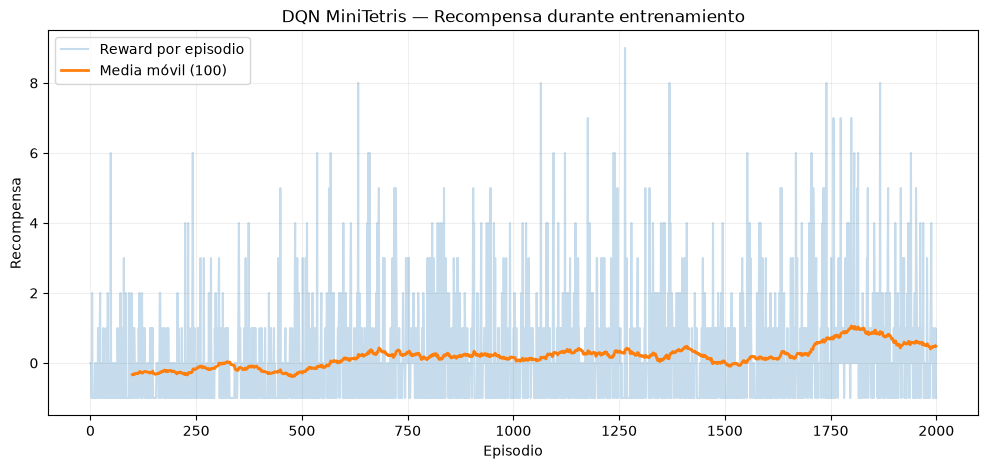

In [61]:
REAL_WINDOW = 100

real_reward_ma = np.convolve(
    real_episode_rewards,
    np.ones(REAL_WINDOW) / REAL_WINDOW,
    mode="valid"
)

plt.figure(figsize=(12, 5))

plt.plot(
    real_episode_rewards,
    alpha=0.25,
    label="Reward por episodio"
)

plt.plot(
    range(
        REAL_WINDOW - 1,
        len(real_episode_rewards)
    ),
    real_reward_ma,
    linewidth=2,
    label=f"Media móvil ({REAL_WINDOW})"
)

plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.title("DQN MiniTetris — Recompensa durante entrenamiento")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Líneas eliminadas

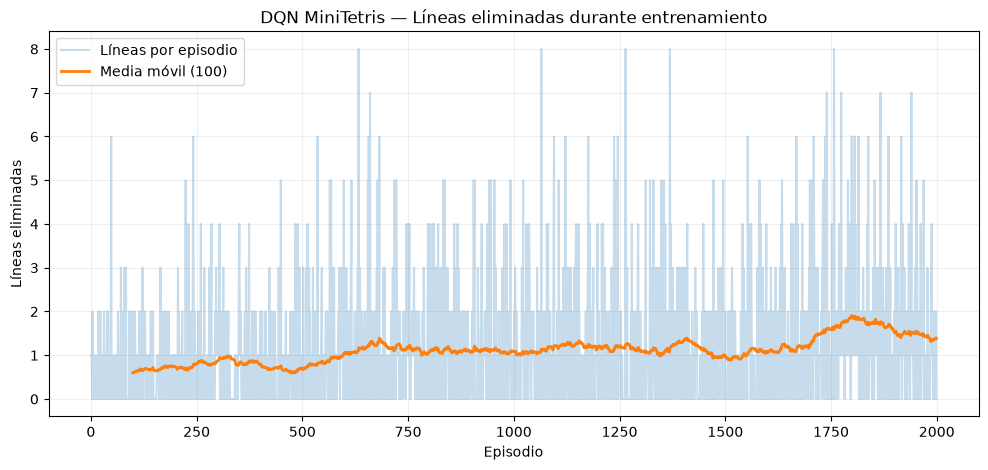

In [62]:
real_lines_ma = np.convolve(
    real_episode_lines,
    np.ones(REAL_WINDOW) / REAL_WINDOW,
    mode="valid"
)

plt.figure(figsize=(12, 5))

plt.plot(
    real_episode_lines,
    alpha=0.25,
    label="Líneas por episodio"
)

plt.plot(
    range(
        REAL_WINDOW - 1,
        len(real_episode_lines)
    ),
    real_lines_ma,
    linewidth=2,
    label=f"Media móvil ({REAL_WINDOW})"
)

plt.xlabel("Episodio")
plt.ylabel("Líneas eliminadas")
plt.title("DQN MiniTetris — Líneas eliminadas durante entrenamiento")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Piezas colocadas / supervivencia

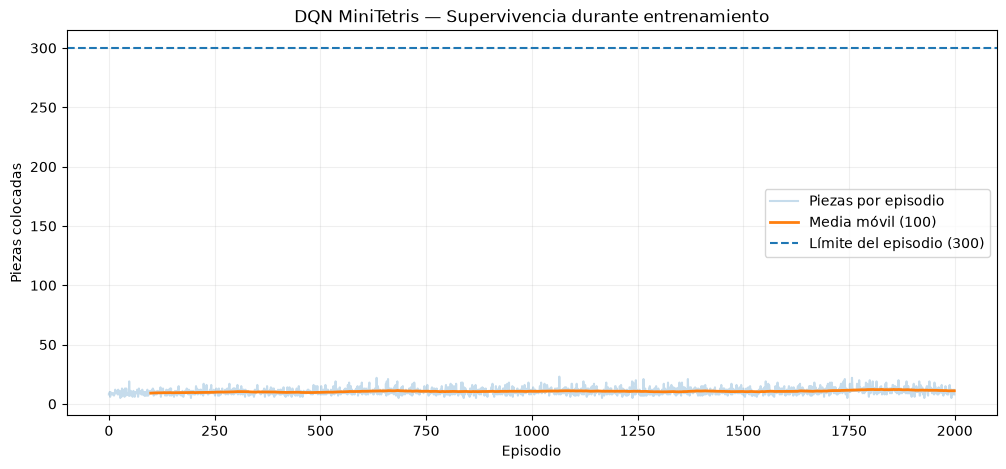

In [63]:
real_pieces_ma = np.convolve(
    real_episode_pieces,
    np.ones(REAL_WINDOW) / REAL_WINDOW,
    mode="valid"
)

plt.figure(figsize=(12, 5))

plt.plot(
    real_episode_pieces,
    alpha=0.25,
    label="Piezas por episodio"
)

plt.plot(
    range(
        REAL_WINDOW - 1,
        len(real_episode_pieces)
    ),
    real_pieces_ma,
    linewidth=2,
    label=f"Media móvil ({REAL_WINDOW})"
)

plt.axhline(
    y=300,
    linestyle="--",
    label="Límite del episodio (300)"
)

plt.xlabel("Episodio")
plt.ylabel("Piezas colocadas")
plt.title("DQN MiniTetris — Supervivencia durante entrenamiento")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Evolución de ε

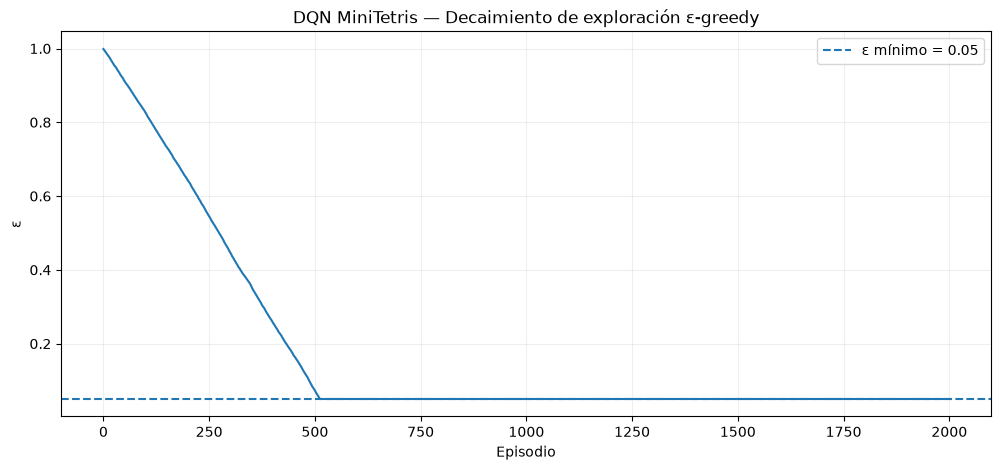

In [64]:
plt.figure(figsize=(12, 5))

plt.plot(
    real_episode_epsilons
)

plt.axhline(
    y=REAL_EPS_END,
    linestyle="--",
    label=f"ε mínimo = {REAL_EPS_END}"
)

plt.xlabel("Episodio")
plt.ylabel("ε")
plt.title("DQN MiniTetris — Decaimiento de exploración ε-greedy")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

### Loss

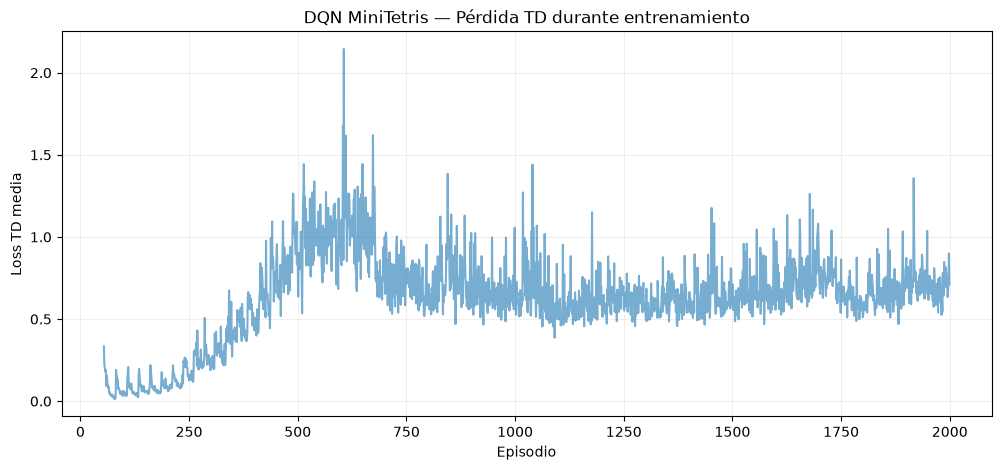

In [65]:
loss_array = np.array(
    real_episode_mean_losses,
    dtype=float
)

valid_loss = ~np.isnan(loss_array)

plt.figure(figsize=(12, 5))

plt.plot(
    np.arange(len(loss_array))[valid_loss],
    loss_array[valid_loss],
    alpha=0.6
)

plt.xlabel("Episodio")
plt.ylabel("Loss TD media")
plt.title("DQN MiniTetris — Pérdida TD durante entrenamiento")
plt.grid(alpha=0.2)

plt.show()

### Saber cuándo ε llegó a 0.05

In [66]:
epsilon_min_episode = next(
    (
        i + 1
        for i, eps in enumerate(
            real_episode_epsilons
        )
        if eps <= REAL_EPS_END + 1e-6
    ),
    None
)

print(
    "ε llegó a",
    REAL_EPS_END,
    "aproximadamente en el episodio:",
    epsilon_min_episode
)

ε llegó a 0.05 aproximadamente en el episodio: 513


### Comparar inicio vs final numéricamente

In [67]:
N_COMPARE = 100

print("=" * 55)
print("COMPARACIÓN INICIO VS FINAL")
print("=" * 55)

print("\nREWARD")
print(
    "Primeros 100:",
    round(
        np.mean(
            real_episode_rewards[:N_COMPARE]
        ),
        2
    )
)

print(
    "Últimos 100:",
    round(
        np.mean(
            real_episode_rewards[-N_COMPARE:]
        ),
        2
    )
)


print("\nLÍNEAS")
print(
    "Primeros 100:",
    round(
        np.mean(
            real_episode_lines[:N_COMPARE]
        ),
        2
    )
)

print(
    "Últimos 100:",
    round(
        np.mean(
            real_episode_lines[-N_COMPARE:]
        ),
        2
    )
)


print("\nPIEZAS")
print(
    "Primeros 100:",
    round(
        np.mean(
            real_episode_pieces[:N_COMPARE]
        ),
        2
    )
)

print(
    "Últimos 100:",
    round(
        np.mean(
            real_episode_pieces[-N_COMPARE:]
        ),
        2
    )
)

COMPARACIÓN INICIO VS FINAL

REWARD
Primeros 100: -0.33
Últimos 100: 0.48

LÍNEAS
Primeros 100: 0.6
Últimos 100: 1.38

PIEZAS
Primeros 100: 9.1
Últimos 100: 11.1


# Experimento 2 — DQN con ε-greedy + inicialización optimista

Para que la comparación sea limpia:

NO cambiamos arquitectura, recompensa, gamma, learning rate, replay buffer, batch size, target update, ε decay, 2000 episodios ni seed.

Solo cambia:

Inicialización de los Q-values.

Así podremos comparar después:

DQN estándar
vs.
DQN ε-greedy + inicialización optimista

## 1. Conservamos la red original

In [68]:
class OptimisticQNetwork(nn.Module):

    def __init__(
        self,
        state_size=67,
        action_size=24,
        optimistic_value=5.0
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                state_size,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                action_size
            )
        )

        # ====================================================
        # INICIALIZACIÓN OPTIMISTA
        # ====================================================

        output_layer = self.network[-1]

        # Pesos pequeños
        nn.init.uniform_(
            output_layer.weight,
            -0.01,
            0.01
        )

        # Todos los Q-values comienzan aproximadamente en +5
        nn.init.constant_(
            output_layer.bias,
            optimistic_value
        )

    def forward(self, state):

        return self.network(state)

## 2. Comprobar la inicializació

In [69]:
OPTIMISTIC_VALUE = 5.0

torch.manual_seed(2026)

test_optimistic_network = OptimisticQNetwork(
    STATE_SIZE,
    ACTION_SIZE,
    optimistic_value=OPTIMISTIC_VALUE
).to(device)

test_env = MiniTetrisEnv(
    max_pieces=300
)

state, info = test_env.reset(
    seed=2026
)

state_tensor = torch.tensor(
    state,
    dtype=torch.float32,
    device=device
).unsqueeze(0)

with torch.no_grad():

    initial_q = test_optimistic_network(
        state_tensor
    )[0]

print("Q-values iniciales:")
print(initial_q)

print(
    "\nPromedio:",
    round(initial_q.mean().item(), 3)
)

Q-values iniciales:
tensor([4.9969, 5.0026, 4.9960, 4.9995, 5.0024, 5.0022, 5.0038, 4.9988, 5.0020,
        5.0057, 5.0004, 5.0005, 5.0070, 5.0018, 5.0040, 5.0015, 4.9996, 4.9968,
        4.9994, 5.0003, 5.0031, 5.0006, 5.0054, 5.0037])

Promedio: 5.001


## 3. Nuevo entrenamiento, sin tocar el anterior

In [79]:
# ============================================================
# EXPERIMENTO OPTIMISTA
# ============================================================

OPT_SEED = 2026

OPT_TRAIN_EPISODES = 2000

OPT_STATE_SIZE = 67
OPT_ACTION_SIZE = 24

OPT_GAMMA = 0.99
OPT_LEARNING_RATE = 1e-3

OPT_BUFFER_SIZE = 20_000
OPT_BATCH_SIZE = 64
OPT_LEARNING_STARTS = 500

OPT_TARGET_UPDATE_FREQ = 250

OPT_EPSILON = 0.0

OPT_MAX_PIECES = 300

OPTIMISTIC_VALUE = 5.0

## 4. Reiniciar seeds

In [80]:
random.seed(OPT_SEED)
np.random.seed(OPT_SEED)
torch.manual_seed(OPT_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(OPT_SEED)

## 5. Crear TODO nuevo

In [81]:
opt_env = MiniTetrisEnv(
    render_mode=None,
    max_pieces=OPT_MAX_PIECES
)


opt_online_network = OptimisticQNetwork(
    OPT_STATE_SIZE,
    OPT_ACTION_SIZE,
    optimistic_value=OPTIMISTIC_VALUE
).to(device)


opt_target_network = OptimisticQNetwork(
    OPT_STATE_SIZE,
    OPT_ACTION_SIZE,
    optimistic_value=OPTIMISTIC_VALUE
).to(device)

opt_target_network.load_state_dict(
    opt_online_network.state_dict()
)

opt_target_network.eval()


opt_optimizer = optim.Adam(
    opt_online_network.parameters(),
    lr=OPT_LEARNING_RATE
)


opt_replay_buffer = ReplayBuffer(
    capacity=OPT_BUFFER_SIZE
)


opt_rng = np.random.default_rng(
    OPT_SEED
)

print("Experimento optimista inicializado ✅")

Experimento optimista inicializado ✅


## 7. Métricas separadas

In [82]:
opt_episode_rewards = []
opt_episode_lines = []
opt_episode_pieces = []
opt_episode_epsilons = []
opt_episode_mean_losses = []

opt_loss_history = []
opt_reached_limit_history = []

opt_global_step = 0

## 8. Entrenamiento completo — DQN optimista

In [83]:
# ============================================================
# ENTRENAMIENTO DQN OPTIMISTA
# ============================================================

opt_training_start = time.perf_counter()

for episode in range(OPT_TRAIN_EPISODES):

    # ========================================================
    # RESET DEL EPISODIO
    # ========================================================

    # Primer episodio con seed 2026.
    # Después dejamos continuar la secuencia aleatoria
    # del entorno normalmente.
    if episode == 0:

        state, info = opt_env.reset(
            seed=OPT_SEED
        )

    else:

        state, info = opt_env.reset()

    episode_reward = 0.0
    episode_losses = []

    terminated = False
    truncated = False

    # ========================================================
    # LOOP DEL EPISODIO
    # ========================================================

    while not (terminated or truncated):

        # ----------------------------------------------------
        # EPSILON OPTIMISTA
        # ----------------------------------------------------
        # No hay epsilon-greedy aleatorio.
        # La exploración proviene de la inicialización
        # optimista de los Q-values.

        epsilon = OPT_EPSILON

        # ----------------------------------------------------
        # SELECCIONAR ACCIÓN
        # ----------------------------------------------------

        action = select_action(
            state=state,
            action_mask=info["action_mask"],
            epsilon=epsilon,
            network=opt_online_network,
            rng=opt_rng
        )

        # ----------------------------------------------------
        # EJECUTAR ACCIÓN
        # ----------------------------------------------------

        (
            next_state,
            reward,
            terminated,
            truncated,
            next_info
        ) = opt_env.step(action)

        # ----------------------------------------------------
        # GUARDAR EXPERIENCIA
        # ----------------------------------------------------

        opt_replay_buffer.add(
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
            terminated=terminated,
            truncated=truncated,
            next_action_mask=next_info["action_mask"]
        )

        # ----------------------------------------------------
        # ENTRENAR RED ONLINE
        # ----------------------------------------------------

        if len(opt_replay_buffer) >= OPT_LEARNING_STARTS:

            loss = train_step(
                replay_buffer=opt_replay_buffer,
                online_network=opt_online_network,
                target_network=opt_target_network,
                optimizer=opt_optimizer,
                batch_size=OPT_BATCH_SIZE,
                gamma=OPT_GAMMA
            )

            if loss is not None:

                episode_losses.append(
                    loss
                )

                opt_loss_history.append(
                    loss
                )

        # ----------------------------------------------------
        # ACTUALIZAR TARGET NETWORK
        # ----------------------------------------------------

        if (
            opt_global_step > 0
            and
            opt_global_step % OPT_TARGET_UPDATE_FREQ == 0
        ):

            opt_target_network.load_state_dict(
                opt_online_network.state_dict()
            )

        # ----------------------------------------------------
        # AVANZAR AL NUEVO ESTADO
        # ----------------------------------------------------

        state = next_state
        info = next_info

        episode_reward += reward

        opt_global_step += 1

    # ========================================================
    # FIN DEL EPISODIO
    # ========================================================

    opt_episode_rewards.append(
        episode_reward
    )

    opt_episode_lines.append(
        info["lines_cleared"]
    )

    opt_episode_pieces.append(
        info["pieces_placed"]
    )

    # Siempre será 0.0 en este experimento
    opt_episode_epsilons.append(
        epsilon
    )

    opt_reached_limit_history.append(
        info["reached_piece_limit"]
    )

    # --------------------------------------------------------
    # LOSS MEDIA DEL EPISODIO
    # --------------------------------------------------------

    if len(episode_losses) > 0:

        mean_episode_loss = float(
            np.mean(episode_losses)
        )

    else:

        mean_episode_loss = np.nan

    opt_episode_mean_losses.append(
        mean_episode_loss
    )

    # ========================================================
    # MOSTRAR PROGRESO CADA 100 EPISODIOS
    # ========================================================

    if (
        episode == 0
        or
        (episode + 1) % 100 == 0
    ):

        last_n = min(
            100,
            len(opt_episode_rewards)
        )

        elapsed = (
            time.perf_counter()
            - opt_training_start
        )

        print(
            f"Episodio "
            f"{episode + 1:4d}/"
            f"{OPT_TRAIN_EPISODES} | "

            f"Pasos={opt_global_step:6d} | "

            f"ε={epsilon:.2f} | "

            f"R100="
            f"{np.mean(opt_episode_rewards[-last_n:]):6.2f} | "

            f"L100="
            f"{np.mean(opt_episode_lines[-last_n:]):6.2f} | "

            f"P100="
            f"{np.mean(opt_episode_pieces[-last_n:]):7.2f} | "

            f"MáxP="
            f"{max(opt_episode_pieces):3d} | "

            f"300="
            f"{sum(opt_reached_limit_history):3d} | "

            f"Tiempo="
            f"{elapsed / 60:.1f} min"
        )

Episodio    1/2000 | Pasos=     8 | ε=0.00 | R100= -1.00 | L100=  0.00 | P100=   8.00 | MáxP=  8 | 300=  0 | Tiempo=0.0 min


Episodio  100/2000 | Pasos=   956 | ε=0.00 | R100= -0.20 | L100=  0.72 | P100=   9.56 | MáxP= 20 | 300=  0 | Tiempo=0.1 min
Episodio  200/2000 | Pasos=  2072 | ε=0.00 | R100=  0.54 | L100=  1.41 | P100=  11.16 | MáxP= 23 | 300=  0 | Tiempo=0.1 min
Episodio  300/2000 | Pasos=  3122 | ε=0.00 | R100=  0.15 | L100=  1.10 | P100=  10.50 | MáxP= 23 | 300=  0 | Tiempo=0.2 min
Episodio  400/2000 | Pasos=  4157 | ε=0.00 | R100=  0.22 | L100=  1.13 | P100=  10.35 | MáxP= 23 | 300=  0 | Tiempo=0.3 min
Episodio  500/2000 | Pasos=  5290 | ε=0.00 | R100=  0.42 | L100=  1.36 | P100=  11.33 | MáxP= 23 | 300=  0 | Tiempo=0.3 min
Episodio  600/2000 | Pasos=  6433 | ε=0.00 | R100=  0.24 | L100=  1.16 | P100=  11.43 | MáxP= 23 | 300=  0 | Tiempo=0.4 min
Episodio  700/2000 | Pasos=  7533 | ε=0.00 | R100=  0.28 | L100=  1.21 | P100=  11.00 | MáxP= 23 | 300=  0 | Tiempo=0.5 min
Episodio  800/2000 | Pasos=  8623 | ε=0.00 | R100=  0.29 | L100=  1.20 | P100=  10.90 | MáxP= 23 | 300=  0 | Tiempo=0.5 min
Episodio

## 9. Guardar el modelo optimista

In [84]:
OPT_MODEL_PATH = (
    "minitetris_dqn_optimistic_seed2026_final.pt"
)

torch.save(
    {
        # ----------------------------------------------------
        # INFORMACIÓN GENERAL
        # ----------------------------------------------------

        "experiment":
            "DQN Optimistic Initialization",

        "seed":
            OPT_SEED,

        "episodes":
            OPT_TRAIN_EPISODES,

        "global_step":
            opt_global_step,

        # ----------------------------------------------------
        # REDES
        # ----------------------------------------------------

        "online_network_state_dict":
            opt_online_network.state_dict(),

        "target_network_state_dict":
            opt_target_network.state_dict(),

        "optimizer_state_dict":
            opt_optimizer.state_dict(),

        # ----------------------------------------------------
        # CONFIGURACIÓN
        # ----------------------------------------------------

        "config": {

            "gamma":
                OPT_GAMMA,

            "learning_rate":
                OPT_LEARNING_RATE,

            "buffer_size":
                OPT_BUFFER_SIZE,

            "batch_size":
                OPT_BATCH_SIZE,

            "learning_starts":
                OPT_LEARNING_STARTS,

            "target_update_freq":
                OPT_TARGET_UPDATE_FREQ,

            "epsilon":
                OPT_EPSILON,

            "optimistic_value":
                OPTIMISTIC_VALUE,

            "max_pieces":
                OPT_MAX_PIECES
        },

        # ----------------------------------------------------
        # MÉTRICAS
        # ----------------------------------------------------

        "episode_rewards":
            opt_episode_rewards,

        "episode_lines":
            opt_episode_lines,

        "episode_pieces":
            opt_episode_pieces,

        "episode_epsilons":
            opt_episode_epsilons,

        "episode_mean_losses":
            opt_episode_mean_losses,

        "reached_limit_history":
            opt_reached_limit_history
    },

    OPT_MODEL_PATH
)

print(
    "Modelo optimista guardado en:",
    OPT_MODEL_PATH
)

Modelo optimista guardado en: minitetris_dqn_optimistic_seed2026_final.pt


## 10. Resumen final

In [85]:
opt_training_time = (
    time.perf_counter()
    - opt_training_start
)

print("\n" + "=" * 65)
print("RESULTADOS — DQN CON INICIALIZACIÓN OPTIMISTA")
print("=" * 65)

print(
    "Seed:",
    OPT_SEED
)

print(
    "Episodios:",
    OPT_TRAIN_EPISODES
)

print(
    "Pasos totales:",
    opt_global_step
)

print(
    "Tiempo total:",
    round(
        opt_training_time / 60,
        2
    ),
    "minutos"
)

print(
    "Experiencias en replay buffer:",
    len(opt_replay_buffer)
)

print(
    "ε:",
    OPT_EPSILON
)

print(
    "Q optimista inicial:",
    OPTIMISTIC_VALUE
)


print(
    "\n--- ÚLTIMOS 100 EPISODIOS ---"
)

print(
    "Reward promedio:",
    round(
        np.mean(
            opt_episode_rewards[-100:]
        ),
        2
    )
)

print(
    "Líneas promedio:",
    round(
        np.mean(
            opt_episode_lines[-100:]
        ),
        2
    )
)

print(
    "Piezas promedio:",
    round(
        np.mean(
            opt_episode_pieces[-100:]
        ),
        2
    )
)


print(
    "\n--- MEJORES RESULTADOS ---"
)

print(
    "Máximo de líneas:",
    max(opt_episode_lines)
)

print(
    "Máximo de piezas:",
    max(opt_episode_pieces)
)

print(
    "Veces que alcanzó 300 piezas:",
    sum(opt_reached_limit_history)
)


RESULTADOS — DQN CON INICIALIZACIÓN OPTIMISTA
Seed: 2026
Episodios: 2000
Pasos totales: 22744
Tiempo total: 3.04 minutos
Experiencias en replay buffer: 20000
ε: 0.0
Q optimista inicial: 5.0

--- ÚLTIMOS 100 EPISODIOS ---
Reward promedio: 1.02
Líneas promedio: 1.84
Piezas promedio: 12.1

--- MEJORES RESULTADOS ---
Máximo de líneas: 9
Máximo de piezas: 24
Veces que alcanzó 300 piezas: 0


## 11. Comparación inicio vs final

In [87]:
N_COMPARE = 100

print("\n" + "=" * 65)
print("OPTIMISTA — COMPARACIÓN INICIO VS FINAL")
print("=" * 65)


print("\nREWARD")

print(
    "Primeros 100:",
    round(
        np.mean(
            opt_episode_rewards[:N_COMPARE]
        ),
        2
    )
)

print(
    "Últimos 100:",
    round(
        np.mean(
            opt_episode_rewards[-N_COMPARE:]
        ),
        2
    )
)


print("\nLÍNEAS")

print(
    "Primeros 100:",
    round(
        np.mean(
            opt_episode_lines[:N_COMPARE]
        ),
        2
    )
)

print(
    "Últimos 100:",
    round(
        np.mean(
            opt_episode_lines[-N_COMPARE:]
        ),
        2
    )
)


print("\nPIEZAS")

print(
    "Primeros 100:",
    round(
        np.mean(
            opt_episode_pieces[:N_COMPARE]
        ),
        2
    )
)

print(
    "Últimos 100:",
    round(
        np.mean(
            opt_episode_pieces[-N_COMPARE:]
        ),
        2
    )
)


OPTIMISTA — COMPARACIÓN INICIO VS FINAL

REWARD
Primeros 100: -0.2
Últimos 100: 1.02

LÍNEAS
Primeros 100: 0.72
Últimos 100: 1.84

PIEZAS
Primeros 100: 9.56
Últimos 100: 12.1


# ¿El agente se estancó por falta de entrenamiento o existe una limitación en la representación/recompensa?

# Experimento 2B — Continuación del DQN optimista hasta 10 000 episodios

Se continúa el entrenamiento del agente optimista previamente entrenado durante 2 000 episodios, sin reinicializar sus pesos ni modificar los hiperparámetros.

In [88]:
OPT_EXTRA_EPISODES = 8000
OPT_TOTAL_EPISODES = 10000

continuation_start = time.perf_counter()

for extra_episode in range(OPT_EXTRA_EPISODES):

    episode_number = (
        len(opt_episode_rewards) + 1
    )

    state, info = opt_env.reset()

    episode_reward = 0.0
    episode_losses = []

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Optimista puro: siempre greedy
        epsilon = OPT_EPSILON

        action = select_action(
            state=state,
            action_mask=info["action_mask"],
            epsilon=epsilon,
            network=opt_online_network,
            rng=opt_rng
        )

        (
            next_state,
            reward,
            terminated,
            truncated,
            next_info
        ) = opt_env.step(action)

        opt_replay_buffer.add(
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
            terminated=terminated,
            truncated=truncated,
            next_action_mask=next_info["action_mask"]
        )

        if len(opt_replay_buffer) >= OPT_LEARNING_STARTS:

            loss = train_step(
                replay_buffer=opt_replay_buffer,
                online_network=opt_online_network,
                target_network=opt_target_network,
                optimizer=opt_optimizer,
                batch_size=OPT_BATCH_SIZE,
                gamma=OPT_GAMMA
            )

            if loss is not None:

                episode_losses.append(loss)
                opt_loss_history.append(loss)

        if (
            opt_global_step > 0
            and
            opt_global_step % OPT_TARGET_UPDATE_FREQ == 0
        ):

            opt_target_network.load_state_dict(
                opt_online_network.state_dict()
            )

        state = next_state
        info = next_info

        episode_reward += reward
        opt_global_step += 1

    # ========================================================
    # MÉTRICAS
    # ========================================================

    opt_episode_rewards.append(
        episode_reward
    )

    opt_episode_lines.append(
        info["lines_cleared"]
    )

    opt_episode_pieces.append(
        info["pieces_placed"]
    )

    opt_episode_epsilons.append(
        OPT_EPSILON
    )

    opt_reached_limit_history.append(
        info["reached_piece_limit"]
    )

    if episode_losses:

        mean_loss = float(
            np.mean(episode_losses)
        )

    else:

        mean_loss = np.nan

    opt_episode_mean_losses.append(
        mean_loss
    )

    # ========================================================
    # PROGRESO CADA 500 EPISODIOS
    # ========================================================

    if episode_number % 500 == 0:

        n = min(
            100,
            len(opt_episode_rewards)
        )

        elapsed = (
            time.perf_counter()
            - continuation_start
        )

        print(
            f"Episodio {episode_number:5d}/"
            f"{OPT_TOTAL_EPISODES} | "
            f"Pasos={opt_global_step:7d} | "
            f"R100={np.mean(opt_episode_rewards[-n:]):6.2f} | "
            f"L100={np.mean(opt_episode_lines[-n:]):6.2f} | "
            f"P100={np.mean(opt_episode_pieces[-n:]):7.2f} | "
            f"MáxP={max(opt_episode_pieces):3d} | "
            f"MáxL={max(opt_episode_lines):3d} | "
            f"300={sum(opt_reached_limit_history):3d} | "
            f"Tiempo extra={elapsed / 60:.1f} min"
        )

Episodio  2500/10000 | Pasos=  28911 | R100=  1.20 | L100=  2.05 | P100=  12.74 | MáxP= 30 | MáxL= 13 | 300=  0 | Tiempo extra=0.4 min
Episodio  3000/10000 | Pasos=  35125 | R100=  1.08 | L100=  2.00 | P100=  12.33 | MáxP= 30 | MáxL= 13 | 300=  0 | Tiempo extra=0.8 min
Episodio  3500/10000 | Pasos=  41377 | R100=  0.87 | L100=  1.72 | P100=  12.20 | MáxP= 30 | MáxL= 13 | 300=  0 | Tiempo extra=1.2 min
Episodio  4000/10000 | Pasos=  47516 | R100=  0.88 | L100=  1.80 | P100=  12.28 | MáxP= 30 | MáxL= 13 | 300=  0 | Tiempo extra=1.5 min
Episodio  4500/10000 | Pasos=  53875 | R100=  1.28 | L100=  2.12 | P100=  12.79 | MáxP= 30 | MáxL= 13 | 300=  0 | Tiempo extra=1.9 min
Episodio  5000/10000 | Pasos=  60134 | R100=  1.10 | L100=  2.05 | P100=  12.77 | MáxP= 30 | MáxL= 13 | 300=  0 | Tiempo extra=2.3 min
Episodio  5500/10000 | Pasos=  66491 | R100=  1.05 | L100=  1.97 | P100=  12.63 | MáxP= 30 | MáxL= 13 | 300=  0 | Tiempo extra=2.8 min
Episodio  6000/10000 | Pasos=  72734 | R100=  1.01 | L1

# Análisis intermedio: dudas, hipótesis y decisiones antes de la política heurística

## 1. Punto de partida

Después de validar el entorno personalizado `MiniTetrisEnv` y comprobar por separado el funcionamiento de los principales componentes de DQN, se realizaron diferentes etapas de entrenamiento con el objetivo de determinar si el agente era capaz de aprender una política útil.

El entorno utilizado tiene las siguientes características principales:

* Tablero de **10 filas × 6 columnas**.
* Siete tetrominós: `I`, `O`, `T`, `S`, `Z`, `J` y `L`.
* Estado compuesto por:

  * 60 valores correspondientes al tablero.
  * 7 valores one-hot correspondientes a la pieza actual.
* Total de **67 entradas** para la red neuronal.
* 24 acciones posibles:

  * 4 rotaciones.
  * 6 posibles columnas.
* Se utiliza una máscara para impedir que el agente seleccione colocaciones físicamente inválidas.
* Cada acción representa directamente una combinación **rotación + columna**.
* La pieza cae automáticamente hasta su posición final.
* El episodio termina naturalmente cuando ya no existen colocaciones válidas (`terminated=True`).
* Se definió un límite artificial de **300 piezas** (`truncated=True`) únicamente para evitar episodios potencialmente infinitos.

La recompensa definida inicialmente fue:

* 0 líneas: `0`
* 1 línea: `+1`
* 2 líneas: `+3`
* 3 líneas: `+5`
* 4 líneas: `+8`
* Game Over: `-1`

No se añadieron recompensas adicionales por supervivencia, altura del tablero, huecos u otras características estructurales.

---

## 2. Entrenamiento piloto

Inicialmente se realizaron **150 episodios** para comprobar que el ciclo completo de DQN funcionara.

Este entrenamiento produjo aproximadamente:

* 1402 pasos totales.
* ε final ≈ `0.73`.
* Reward promedio de los últimos 20 episodios: `-0.4`.
* Líneas promedio: `0.6`.
* Piezas promedio: `9.4`.
* Máximo de piezas: `19`.

Las curvas no mostraron una mejora clara.

Sin embargo, este resultado no se interpretó como una falla del algoritmo, porque el entrenamiento era demasiado corto y el agente todavía exploraba aproximadamente el 73 % de las veces.

Por esta razón se decidió realizar un entrenamiento considerablemente más largo antes de modificar la arquitectura, la recompensa o cualquier otro hiperparámetro.

---

## 3. DQN estándar con ε-greedy

Se reinicializó completamente el agente y se entrenó durante **2000 episodios** utilizando:

* Seed: `2026`.
* γ = `0.99`.
* Learning rate = `0.001`.
* Replay buffer = `20000`.
* Batch size = `64`.
* Inicio del aprendizaje después de 500 experiencias.
* Actualización de la target network cada 250 pasos.
* ε inicial = `1.0`.
* ε mínimo = `0.05`.
* Decaimiento de ε durante 5000 pasos.

El entrenamiento produjo:

* 21152 pasos totales.
* ε alcanzó `0.05` aproximadamente en el episodio 513.
* Reward promedio últimos 100: `0.48`.
* Líneas promedio últimos 100: `1.38`.
* Piezas promedio últimos 100: `11.1`.
* Máximo de líneas: `8`.
* Máximo de piezas: `23`.
* Veces que alcanzó 300 piezas: `0`.

La comparación entre los primeros y últimos 100 episodios fue:

| Métrica | Primeros 100 | Últimos 100 |
| ------- | -----------: | ----------: |
| Reward  |        -0.33 |        0.48 |
| Líneas  |         0.60 |        1.38 |
| Piezas  |         9.10 |       11.10 |

### Primera conclusión

Existió aprendizaje.

El aumento en recompensa, líneas eliminadas y supervivencia indica que la red desarrolló una política mejor que la inicial.

Sin embargo, el aumento de supervivencia fue pequeño comparado con la mejora en eliminación de líneas.

Esto generó una primera pregunta:

> **¿El agente está aprendiendo principalmente a obtener líneas, pero no a construir un tablero sostenible a largo plazo?**

---

## 4. DQN con inicialización optimista

Posteriormente se decidió probar una estrategia utilizada anteriormente en aprendizaje tabular: **inicialización optimista**.

En DQN no existe una tabla Q que pueda inicializarse directamente. Por esta razón, se modificó la capa de salida de la red para que inicialmente sus valores Q fueran aproximadamente:

[
Q(s,a) \approx 5
]

La exploración fue completamente greedy:

[
\epsilon = 0
]

La idea fue permitir que el optimismo inicial de los Q-values incentivara la exploración sin utilizar acciones aleatorias.

Todos los demás hiperparámetros se mantuvieron iguales para hacer una comparación lo más limpia posible.

Después de **2000 episodios**, se obtuvo:

* 22744 pasos.
* Reward promedio últimos 100: `1.02`.
* Líneas promedio últimos 100: `1.84`.
* Piezas promedio últimos 100: `12.1`.
* Máximo de líneas: `9`.
* Máximo de piezas: `24`.

Comparación:

| Métrica            | DQN estándar | DQN optimista |
| ------------------ | -----------: | ------------: |
| Reward últimos 100 |         0.48 |      **1.02** |
| Líneas últimos 100 |         1.38 |      **1.84** |
| Piezas últimos 100 |         11.1 |      **12.1** |
| Máximo líneas      |            8 |         **9** |
| Máximo piezas      |           23 |        **24** |

### Segunda conclusión

La inicialización optimista produjo mejores resultados que ε-greedy estándar bajo esta configuración.

Sin embargo, apareció una nueva duda importante:

> **Aunque el optimista obtiene mejores recompensas y elimina más líneas, ¿por qué el máximo de supervivencia continúa alrededor de 23–24 piezas?**

---

## 5. Hipótesis: quizá faltaba entrenamiento

Una explicación posible era simplemente que **2000 episodios todavía fueran insuficientes**.

Por esta razón se continuó entrenando el mismo agente optimista, sin reinicializar pesos ni modificar hiperparámetros, hasta alcanzar **10000 episodios totales**.

Esta prueba fue importante porque permitió analizar únicamente el efecto de proporcionar más experiencia al mismo agente.

Algunos resultados durante esta continuación fueron:

| Episodio | Líneas promedio últimas 100 | Piezas promedio últimas 100 | Máximo piezas | Máximo líneas |
| -------: | --------------------------: | --------------------------: | ------------: | ------------: |
|     2500 |                        2.05 |                       12.74 |            30 |            13 |
|     3000 |                        2.00 |                       12.33 |            30 |            13 |
|     4000 |                        1.80 |                       12.28 |            30 |            13 |
|     5000 |                        2.05 |                       12.77 |            30 |            13 |
|     6500 |                        2.24 |                       13.01 |            30 |            13 |
|     7500 |                        1.99 |                       12.51 |            30 |            13 |
|     8500 |                        2.27 |                       13.04 |            30 |            13 |
|     9500 |                        1.84 |                       12.32 |            30 |            13 |
|    10000 |                        1.92 |                       12.48 |            30 |            13 |

Al finalizar:

* Pasos totales: aproximadamente `123793`.
* Máximo de piezas: `30`.
* Máximo de líneas: `13`.
* El límite de 300 piezas nunca fue alcanzado.

---

## 6. Evidencia de un posible techo de aprendizaje

Entre aproximadamente los episodios 2500 y 10000, la supervivencia promedio permanece normalmente entre:

[
12 y 13  piezas
]

y el récord permanece en:

[
30 piezas
]

durante miles de episodios.

Por lo tanto, la hipótesis:

> **“El agente simplemente necesita más entrenamiento”**

pierde fuerza.

El agente recibió más de 120000 interacciones y continuó actualizando sus pesos, pero la mejora adicional fue muy pequeña.

Esto sugiere la existencia de un **techo de aprendizaje bajo la configuración actual**.

---

## 7. Preguntas que aparecen a partir del estancamiento

El estancamiento puede tener varias causas y todavía no existe suficiente evidencia para atribuirlo a una sola.

### Hipótesis A — Limitación causada por el tamaño del tablero

El tablero solamente tiene:

[
10 x 6
]

Es posible que seis columnas produzcan configuraciones particularmente difíciles y que pequeños errores generen rápidamente situaciones irreversibles.

Sin embargo, esto **no implica matemáticamente que el agente solamente pueda colocar 30 piezas**.

Como las filas completas desaparecen, teóricamente una buena política podría continuar durante mucho más tiempo.

Por tanto, el tamaño del tablero puede aumentar la dificultad, pero todavía no sabemos si explica por sí solo el techo observado.

---

### Hipótesis B — La función de recompensa enseña a eliminar líneas, pero no a sobrevivir

Actualmente la recompensa informa directamente al agente sobre:

> **“Eliminar líneas es bueno.”**

Sin embargo, no informa explícitamente sobre características como:

* número de huecos;
* altura total del tablero;
* altura máxima;
* irregularidad de la superficie;
* columnas peligrosamente altas;
* espacios encerrados difíciles de completar.

Una acción puede no producir una penalización inmediata y aun así dejar el tablero en una configuración muy mala para varias piezas posteriores.

Esto podría explicar por qué las líneas eliminadas aumentaron considerablemente mientras la supervivencia aumentó mucho menos.

---

### Hipótesis C — Información insuficiente en el estado

El agente observa:

* tablero actual;
* pieza actual.

No observa:

* siguiente pieza;
* piezas futuras;
* sistema `hold`.

Por lo tanto, dos configuraciones idénticas con diferentes piezas siguientes son indistinguibles para la política actual hasta que la siguiente pieza aparece.

Esto introduce incertidumbre adicional.

---

### Hipótesis D — Generación de piezas

Las piezas se generan aleatoriamente de manera independiente.

No se implementó el sistema moderno de Tetris conocido como **7-bag**, en el cual aparecen todas las piezas antes de volver a llenar la bolsa.

La generación independiente puede producir secuencias particularmente desfavorables.

---

### Hipótesis E — Representación espacial

El tablero 10×6 se transforma en un vector de 60 valores y se introduce en una MLP:

[
67 -> 128 -> 128 -> 24
]

La red debe aprender por sí misma relaciones espaciales como:

* qué bloques están encima de otros;
* qué constituye un hueco;
* qué columnas forman una superficie;
* qué patrones son peligrosos.

Una arquitectura que explote explícitamente la estructura espacial podría representar mejor el problema.

Sin embargo, cambiar inmediatamente la arquitectura impediría determinar si realmente este es el problema principal.

---

### Hipótesis F — Limitaciones de la inicialización optimista en DQN

En aprendizaje tabular, cada valor:

[
Q(s,a)
]

es independiente.

En DQN, los estados comparten los mismos pesos de la red neuronal.

Actualizar la estimación de una experiencia puede modificar indirectamente estimaciones de otros estados.

Por esta razón, la inicialización optimista no produce exactamente el mismo comportamiento que en Q-Learning tabular.

Aun así, bajo este experimento produjo mejores resultados que ε-greedy estándar.

---

## 8. Una pregunta que todavía no podemos responder

En este momento existe una ambigüedad:

> **¿El agente DQN se estanca porque su aprendizaje es insuficiente o porque nuestro entorno de MiniTetris es inherentemente muy difícil bajo estas reglas?**

Observar solamente al DQN no permite separar ambas posibilidades.

Necesitamos una referencia externa.

---

# 9. Próximo experimento: política heurística

Antes de modificar:

* recompensa;
* red neuronal;
* tamaño del tablero;
* representación del estado;
* distribución de piezas;

se implementará una **política heurística sin aprendizaje**.

Esta política evaluará todas las colocaciones válidas disponibles y seleccionará la que produzca el tablero considerado más conveniente según características conocidas del estado.

La heurística podrá considerar, por ejemplo:

* líneas eliminadas;
* cantidad de huecos;
* altura agregada de las columnas;
* altura máxima;
* irregularidad o diferencia entre columnas.

La heurística **no aprenderá** y no utilizará DQN.

Simplemente aplicará reglas razonables para seleccionar una colocación.

---

## 10. ¿Por qué hacer una heurística?

El objetivo principal no es superar al DQN ni convertirla en nuestra solución final.

La utilizaremos como **baseline de diagnóstico del entorno**.

Nos permitirá separar dos posibilidades.

### Caso 1 — La heurística juega mucho mejor

Por ejemplo:

```text
DQN:
máximo ≈ 30 piezas

Heurística:
100, 200 o incluso 300 piezas
```

Esto indicaría que el entorno **sí permite políticas considerablemente mejores**.

Por tanto, el techo observado sería principalmente una limitación del agente DQN actual, posiblemente relacionada con:

* recompensa;
* representación;
* arquitectura;
* estrategia de exploración;
* hiperparámetros.

---

### Caso 2 — La heurística también pierde rápidamente

Por ejemplo:

```text
DQN:
máximo ≈ 30 piezas

Heurística:
máximo ≈ 30–40 piezas
```

Esto indicaría que las características propias del entorno:

* tablero 10×6;
* generación aleatoria de piezas;
* ausencia de información futura;
* ausencia de hold;
* sistema de colocación;

hacen que sobrevivir durante períodos largos sea intrínsecamente difícil.

En ese caso tendría más sentido modificar el entorno antes que seguir entrenando el DQN indefinidamente.

---

## 11. Estado actual de las conclusiones

Hasta este punto podemos afirmar con los resultados obtenidos que:

1. **El DQN sí aprende.**
   Las recompensas, las líneas eliminadas y la supervivencia mejoraron respecto al inicio.

2. **La inicialización optimista funcionó mejor que ε-greedy estándar** bajo la configuración utilizada.

3. **Más entrenamiento ayudó inicialmente**, elevando el máximo de 24 a 30 piezas y el máximo de líneas de 9 a 13.

4. **Después apareció un estancamiento fuerte.**
   Entre miles de episodios posteriores, la supervivencia promedio se mantuvo aproximadamente entre 12 y 13 piezas y el récord permaneció en 30.

5. **No parece razonable atribuir el problema únicamente a falta de entrenamiento.**

6. **Todavía no podemos afirmar que el tablero 10×6 sea el responsable del techo.**

7. Antes de modificar DQN o el entorno, necesitamos comprobar cuánto rendimiento permite realmente el entorno utilizando una política razonable que no dependa de aprendizaje.

Por esta razón, el siguiente paso será implementar y evaluar una **política heurística como baseline de diagnóstico**.


# Heurística — baseline de diagnóstico

Ahora sí vamos a comprobar si nuestro MiniTetris permite jugar considerablemente mejor que las ~30 piezas del DQN.

La heurística no aprende nada.

En cada estado:

1. mira todas las acciones válidas;
2. simula cómo quedaría el tablero después de cada una;
3. calcula características del tablero;
4. asigna una puntuación;
5. escoge la mejor colocación.

No modifica nuestro entorno ni nuestro DQN.

In [89]:
def get_board_features(board):

    rows, cols = board.shape

    heights = []
    holes = 0

    # ========================================================
    # ALTURAS Y HUECOS
    # ========================================================

    for col in range(cols):

        column = board[:, col]

        filled = np.flatnonzero(
            column
        )

        if len(filled) == 0:

            height = 0

        else:

            first_filled = filled[0]

            height = (
                rows
                - first_filled
            )

            # Celdas vacías debajo del
            # primer bloque de la columna
            holes += int(
                np.sum(
                    column[
                        first_filled:
                    ] == 0
                )
            )

        heights.append(
            height
        )

    heights = np.array(
        heights,
        dtype=np.float32
    )

    aggregate_height = float(
        np.sum(heights)
    )

    max_height = float(
        np.max(heights)
    )

    bumpiness = float(
        np.sum(
            np.abs(
                np.diff(heights)
            )
        )
    )

    return {
        "aggregate_height":
            aggregate_height,

        "max_height":
            max_height,

        "holes":
            holes,

        "bumpiness":
            bumpiness
    }

## Simular una acción SIN modificar el entorno

In [90]:
def simulate_action(
    env,
    action
):

    rotation = (
        action // env.cols
    )

    column = (
        action % env.cols
    )

    shape = env._get_rotated_piece(
        env.current_piece_idx,
        rotation
    )

    row = env._find_drop_row(
        shape,
        column
    )

    if row is None:
        return None

    # Copia del tablero.
    # El entorno REAL no se modifica.
    simulated_board = (
        env.board.copy()
    )

    height, width = shape.shape

    simulated_board[
        row:row + height,
        column:column + width
    ] |= shape

    # ========================================================
    # ELIMINAR LÍNEAS SIMULADAS
    # ========================================================

    full_rows = np.all(
        simulated_board == 1,
        axis=1
    )

    lines_cleared = int(
        np.sum(full_rows)
    )

    if lines_cleared > 0:

        remaining_rows = (
            simulated_board[
                ~full_rows
            ]
        )

        empty_rows = np.zeros(
            (
                lines_cleared,
                env.cols
            ),
            dtype=np.int8
        )

        simulated_board = np.vstack(
            [
                empty_rows,
                remaining_rows
            ]
        )

    return (
        simulated_board,
        lines_cleared
    )

## Función de puntuación heurística

Aquí sí estamos introduciendo una decisión nuestra.

Vamos a favorecer:

borrar líneas;

y penalizar:

huecos;
altura total;
altura máxima;
irregularidad.

Primera versión:

In [91]:
def heuristic_score(
    board,
    lines_cleared
):

    features = get_board_features(
        board
    )

    score = (
        3.0
        * lines_cleared

        - 1.5
        * features["holes"]

        - 0.45
        * features["aggregate_height"]

        - 0.35
        * features["bumpiness"]

        - 0.20
        * features["max_height"]
    )

    return score

Los pesos no están optimizados.

Eso es importante.

No queremos construir “el mejor bot de Tetris”; queremos una política razonable que nos diga si nuestro entorno permite sobrevivir mucho más.

## Seleccionar la mejor acción

In [92]:
def select_heuristic_action(
    env,
    action_mask
):

    valid_actions = np.flatnonzero(
        action_mask
    )

    if len(valid_actions) == 0:

        raise ValueError(
            "No existen acciones válidas."
        )

    best_action = None
    best_score = -np.inf

    for action in valid_actions:

        result = simulate_action(
            env,
            int(action)
        )

        if result is None:
            continue

        (
            simulated_board,
            lines_cleared
        ) = result

        score = heuristic_score(
            simulated_board,
            lines_cleared
        )

        if score > best_score:

            best_score = score
            best_action = int(
                action
            )

    return best_action

In [94]:
# ============================================================
# SEEDS DINÁMICAS Y REPRODUCIBLES POR EPISODIO
# ============================================================

def get_episode_seed(run_seed, episode):

    seed_sequence = np.random.SeedSequence(
        [run_seed, episode]
    )

    episode_seed = int(
        seed_sequence.generate_state(1)[0]
    )

    return episode_seed

## Primera partida heurística

In [95]:
HEURISTIC_RUN_SEED = 2026

heuristic_env = MiniTetrisEnv(
    render_mode=None,
    max_pieces=300
)

episode_seed = get_episode_seed(
    HEURISTIC_RUN_SEED,
    0
)

state, info = heuristic_env.reset(
    seed=episode_seed
)

terminated = False
truncated = False

total_reward = 0.0

while not (
    terminated
    or truncated
):

    action = (
        select_heuristic_action(
            heuristic_env,
            info["action_mask"]
        )
    )

    (
        state,
        reward,
        terminated,
        truncated,
        info
    ) = heuristic_env.step(
        action
    )

    total_reward += reward


print("=" * 50)
print("PRIMERA PARTIDA HEURÍSTICA")
print("=" * 50)

print(
    "Run seed:",
    HEURISTIC_RUN_SEED
)

print(
    "Episode seed:",
    episode_seed
)

print(
    "Reward:",
    total_reward
)

print(
    "Líneas:",
    info["lines_cleared"]
)

print(
    "Piezas:",
    info["pieces_placed"]
)

print(
    "Terminated:",
    terminated
)

print(
    "Truncated:",
    truncated
)

PRIMERA PARTIDA HEURÍSTICA
Run seed: 2026
Episode seed: 2727543821
Reward: 64.0
Líneas: 54
Piezas: 93
Terminated: True
Truncated: False


## Evaluación seria — 100 episodios

In [96]:
HEURISTIC_EPISODES = 100
HEURISTIC_RUN_SEED = 2026

heuristic_rewards = []
heuristic_lines = []
heuristic_pieces = []
heuristic_reached_limit = []
heuristic_episode_seeds = []

heuristic_env = MiniTetrisEnv(
    render_mode=None,
    max_pieces=300
)


for episode in range(
    HEURISTIC_EPISODES
):

    episode_seed = (
        get_episode_seed(
            HEURISTIC_RUN_SEED,
            episode
        )
    )

    heuristic_episode_seeds.append(
        episode_seed
    )

    state, info = heuristic_env.reset(
        seed=episode_seed
    )

    terminated = False
    truncated = False

    total_reward = 0.0

    while not (
        terminated
        or truncated
    ):

        action = (
            select_heuristic_action(
                heuristic_env,
                info["action_mask"]
            )
        )

        (
            state,
            reward,
            terminated,
            truncated,
            info
        ) = heuristic_env.step(
            action
        )

        total_reward += reward

    heuristic_rewards.append(
        total_reward
    )

    heuristic_lines.append(
        info["lines_cleared"]
    )

    heuristic_pieces.append(
        info["pieces_placed"]
    )

    heuristic_reached_limit.append(
        info["reached_piece_limit"]
    )

## Resultados

In [97]:
print("\n" + "=" * 60)
print("RESULTADOS — POLÍTICA HEURÍSTICA")
print("=" * 60)

print(
    "Run seed:",
    HEURISTIC_RUN_SEED
)

print(
    "Episodios:",
    HEURISTIC_EPISODES
)

print(
    "\n--- PROMEDIOS ---"
)

print(
    "Reward:",
    round(
        np.mean(
            heuristic_rewards
        ),
        2
    )
)

print(
    "Líneas:",
    round(
        np.mean(
            heuristic_lines
        ),
        2
    )
)

print(
    "Piezas:",
    round(
        np.mean(
            heuristic_pieces
        ),
        2
    )
)


print(
    "\n--- VARIABILIDAD ---"
)

print(
    "Desv. líneas:",
    round(
        np.std(
            heuristic_lines
        ),
        2
    )
)

print(
    "Desv. piezas:",
    round(
        np.std(
            heuristic_pieces
        ),
        2
    )
)


print(
    "\n--- MEJORES RESULTADOS ---"
)

print(
    "Máximo líneas:",
    max(
        heuristic_lines
    )
)

print(
    "Máximo piezas:",
    max(
        heuristic_pieces
    )
)

print(
    "Mínimo piezas:",
    min(
        heuristic_pieces
    )
)

print(
    "Llegó a 300:",
    sum(
        heuristic_reached_limit
    ),
    "de",
    HEURISTIC_EPISODES
)


RESULTADOS — POLÍTICA HEURÍSTICA
Run seed: 2026
Episodios: 100

--- PROMEDIOS ---
Reward: 37.88
Líneas: 33.69
Piezas: 61.45

--- VARIABILIDAD ---
Desv. líneas: 25.07
Desv. piezas: 37.7

--- MEJORES RESULTADOS ---
Máximo líneas: 125
Máximo piezas: 199
Mínimo piezas: 11
Llegó a 300: 0 de 100


# Conclusión después de la política heurística

Los resultados de la política heurística permiten descartar que el bajo rendimiento del DQN se deba principalmente a una limitación física del entorno MiniTetris 10×6.

Mientras que el DQN con inicialización optimista, incluso después de 10 000 episodios y 123 793 interacciones, alcanzó un máximo de 30 piezas y mantuvo una supervivencia promedio cercana a 12–13 piezas, la política heurística consiguió en 100 episodios un promedio de 61.45 piezas, un máximo de 199 piezas, un promedio de 33.69 líneas eliminadas y un máximo de 125 líneas.

Esto demuestra que el entorno permite políticas considerablemente mejores que las aprendidas por el DQN actual. Por lo tanto, el estancamiento observado no puede atribuirse únicamente al tamaño del tablero ni a que el problema sea inherentemente incapaz de sostener partidas largas.

La principal diferencia es que la heurística evalúa directamente características estructurales del tablero, como los huecos, la altura y la irregularidad de la superficie, mientras que el DQN solo recibe recompensas explícitas al eliminar líneas y una penalización al perder. Esto sugiere que el agente puede estar recibiendo una señal demasiado escasa o tardía para identificar qué colocaciones deterioran el tablero a largo plazo.

Sin embargo, todavía no puede concluirse que la función de recompensa sea la única responsable. La estrategia de exploración y la representación del estado también pueden limitar el aprendizaje. Por esta razón, antes de modificar la recompensa o la arquitectura, resulta útil probar una estrategia de exploración adicional y observar si permite superar el techo actual.

# Demostración visual del agente entrenado

Se ejecuta una partida completa utilizando el DQN optimista entrenado, sin actualizar sus pesos.

Durante esta evaluación el agente utiliza una política completamente greedy (`ε = 0`) y el entorno se renderiza después de cada acción para observar visualmente su comportamiento.

## Crear un entorno únicamente para la demostración

In [98]:
# ============================================================
# ENTORNO VISUAL PARA DEMOSTRACIÓN
# ============================================================

visual_env = MiniTetrisEnv(
    render_mode="human",
    max_pieces=300
)

VISUAL_RUN_SEED = 2026
VISUAL_EPISODE = 0

visual_seed = get_episode_seed(
    VISUAL_RUN_SEED,
    VISUAL_EPISODE
)

print(
    "Seed de la demostración:",
    visual_seed
)

Seed de la demostración: 2727543821


## Ejecutar una partida con el agente entrenado

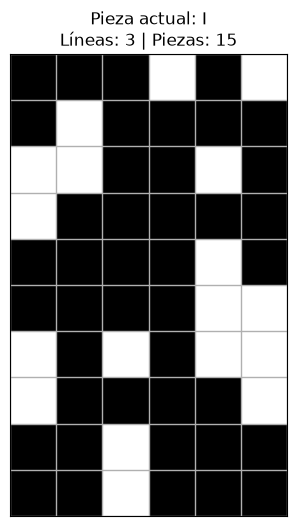

In [100]:
# ============================================================
# PARTIDA VISUAL — DQN OPTIMISTA ENTRENADO
# ============================================================

opt_online_network.eval()

state, info = visual_env.reset(
    seed=visual_seed
)

terminated = False
truncated = False

total_reward = 0.0
steps = 0

# Mostrar tablero inicial
visual_env.render()

while not (terminated or truncated):

    # --------------------------------------------------------
    # ACCIÓN GREEDY DEL AGENTE ENTRENADO
    # --------------------------------------------------------

    action = select_action(
        state=state,
        action_mask=info["action_mask"],
        epsilon=0.0,
        network=opt_online_network,
        rng=opt_rng
    )

    # --------------------------------------------------------
    # EJECUTAR ACCIÓN
    # --------------------------------------------------------

    (
        next_state,
        reward,
        terminated,
        truncated,
        next_info
    ) = visual_env.step(action)

    total_reward += reward
    steps += 1

    state = next_state
    info = next_info

    # --------------------------------------------------------
    # MOSTRAR RESULTADO DE LA ACCIÓN
    # --------------------------------------------------------

    visual_env.render()

    # Velocidad de la animación
    time.sleep(0.30)